Lab Group: SDAB GROUP 9
Group Members: Chan Chun Mun Aloycius, Aw Hongkai, Koh Tat Yao


In [ ]:
#ALL RELEVANT IMPORTS FOR THE NOTEBOOK
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

## **Problem Statement**


### How can we use behavioural sequences and account metadata to develop a classification model that can better distinguish automated bots from human users?

## *Hypothesis/Analysis Goal* (Ask)

Automated bots on social media platforms have become increasingly sophisticated, blurring the lines between human and machine-generated content. This poses a significant threat to digital integrity, particularly on social media platforms like Twitter and Reddit, where bots can imitate human behaviour and spread misinformation that could potentially manipulate public opinion and cause harm. As a result, it makes it increasingly difficult for both users and platforms to distinguish between genuine human interactions and automated activity.

The aim of our project is to create a classification model that is able to tell apart humans from bot accounts by analysing various user behaviour data along with account metadata. We aim to explore the correlation between the accounts’ digital footprint and the potential of an account being a bot.

Findings from our project will have wide-reaching applications beyond social media in areas such as E-commerce, cybersecurity, financial services and many more. By developing an effective model to distinguish humans from bot accounts, we can better detect scalping bots in E-commerce platforms, malicious bots in cyber attacks and financial scams.

Our analysis aims to produce an effective model capable of detecting across multiple platforms while maintaining accurate detection to safeguard online communities.


## **Data Source Identification and Exploration (Prepare)**


Requirement analysis: In order to develop a classification model, we would require data that includes a wide range of “digital footprints” across multiple social platforms. It is crucial to have datasets that include both metadata and user behavioural activity logs in order to identify the key correlations within an account’s digital footprint that shows signs of automation. We will focus on relevant data that will enable us to better analyse the bots’ behaviour from humans while ignoring data like gender, birthdate etc that are irrelevant features.

Some examples of account metadata we have includes account age, follower count, friends count, likes count and favourites count. While for behavioural activities we have average word length, average tweets per day, reply delay, URLs, hashtags and the user’s language use.


### *List of considered sources*

We identified and explored datasets representing different social media platforms to fulfill the multi-source requirements:

<br>

https://www.kaggle.com/datasets/nudratabbas/the-dead-internet-theory-reddit-bot-vs-human

This source provides behavioural data on the Reddit platform focusing on the word length and interaction frequencies within the platform.

<br>

https://www.kaggle.com/datasets/danieltreiman/twitter-human-bots-dataset

This source contains profile metadata for roughly 37,000 accounts which enables us to establish our baseline between the automated and real account characteristics.

<br>

https://www.kaggle.com/datasets/juice0lover/users-vs-bots-classification

This dataset includes user profile data and activity logs from a Russian social media platform.

<br>

https://www.kaggle.com/datasets/sudishbasnet/truthseekertwitterdataset2023?select=Twitter+Analysis.csv

This dataset contains a collection of tweet metadata and account labels with a mix of linguistic and behavioural features.


### Dataset 1: Dead Internet Theory Reddit Bot vs Human dataset

**Description**

The dataset reddit_dead_internet_analysis_2026.csv provides a snapshot of Reddit comment activity, specifically curated to analyze the "Dead Internet Theory" — the hypothesis that a significant portion of internet engagement is generated by automated agents.

The data includes metadata containing 500 records, featuring:

*   Account Metrics (account age days, user karma)
*   Behavioral Metrics (reply delay, average word length, contains links)
*   Contextual Data (subreddit category, sentiment score)
*   Classification Ground Truth (bot flag, bot label type, bot probability)

Upon initial inspection, the dataset is well-structured and maps directly to our requirements for identifying patterns in automated vs. human discourse across major subreddits like gaming, technology, and worldnews.

The following code imports the dataset into a data frame and displays the first few rows.

In [ ]:
df_reddit = pd.read_csv('reddit_dead_internet_analysis_2026.csv')
print(df_reddit.head())


      comment_id subreddit  ...  bot_type_label  bot_probability
0  t1_3148938807     funny  ...    None (Human)            0.093
1  t1_2516748923    gaming  ...    None (Human)            0.117
2   t1_833922318  politics  ...    None (Human)            0.115
3  t1_3987809057     funny  ...    None (Human)            0.094
4  t1_3931039688    gaming  ...    None (Human)            0.116

[5 rows x 11 columns]


**Exploration of Dataset Columns**


The following code displays all columns of the data frame and checks for any columns containing missing or NULL values.

In [ ]:
print(df_reddit.columns)
num_rows = df_reddit.shape[0]
print(f"Number of rows: {num_rows}")
print(f"This dataset contains missing/NULL values: {df_reddit.isnull().any().any()}")


Index(['comment_id', 'subreddit', 'account_age_days', 'user_karma',
       'reply_delay_seconds', 'sentiment_score', 'avg_word_length',
       'contains_links', 'is_bot_flag', 'bot_type_label', 'bot_probability'],
      dtype='object')
Number of rows: 500
This dataset contains missing/NULL values: False


**Exploration of Target Class Distribution**




Checking the target class distribution *is_bot_flag* to establish baseline probabilities. The output indicates the count of human and bot interactions and the relative proportion of each class.

In [ ]:
# Target Variable Distribution
print("--- Class Distribution ---")
class_counts = df_reddit['is_bot_flag'].value_counts()
print(class_counts)
print(df_reddit['is_bot_flag'].value_counts(normalize=True) * 100)

--- Class Distribution ---
is_bot_flag
False    282
True     218
Name: count, dtype: int64
is_bot_flag
False    56.4
True     43.6
Name: proportion, dtype: float64


We can see that from the dataset, approximately 56.4% of interactions are human while 43.6% are bots. This significant volume of automated content provides a robust foundation for statistical comparison.

To determine the suitability of this data, we must investigate how clearly bot behavior is distinguished from human behavior and whether certain subreddits are more susceptible to automation.

In [ ]:
# Bot Type Breakdown
print("--- Bot Type Breakdown ---")
print(df_reddit['bot_type_label'].value_counts())

print()

# Mean Bot Probability per Subreddit
subreddit_analysis = df_reddit.groupby('subreddit')['bot_probability'].mean().sort_index()
print("--- Average Bot Probability by Subreddit ---")
print(subreddit_analysis)

print()

# Bot prevalence by Subreddit (Percentage)
subreddit_stats = df_reddit.groupby('subreddit')['is_bot_flag'].mean().sort_values(ascending=False)
print("--- Bot Percentage per Subreddit ---")
print(subreddit_stats * 100)


--- Bot Type Breakdown ---
bot_type_label
None (Human)         282
Engagement Farmer     86
AI Summarizer         66
Reprint Bot           66
Name: count, dtype: int64

--- Average Bot Probability by Subreddit ---
subreddit
funny         0.146734
gaming        0.163761
pics          0.155000
politics      0.159855
technology    0.149389
worldnews     0.164449
Name: bot_probability, dtype: float64

--- Bot Percentage per Subreddit ---
subreddit
gaming        48.913043
worldnews     48.717949
pics          41.975309
technology    41.666667
politics      40.963855
funny         39.361702
Name: is_bot_flag, dtype: float64


**Bot Breakdown and Subreddit Trends**

Looking at the Bot Type Breakdown, we see a diverse mix of bots like Engagement Farmers, AI Summarizers, and Reprint Bots. This suggests that different bots have different functionalities, where some are meant to farm karma/visibility, while others are churning out summaries.

When we look at Subreddit Prevalence, we can see that automation is everywhere in this dataset. Every subreddit we sampled has a significant bot presence, with the most prevalent ones being found in gaming and worldnews where there are nearly 49% of the interactions coming from non-human accounts.

**Why this matters for our Model**

From a modeling perspective, this is a great starting point. Since the bot types are relatively evenly distributed and show up across all the different subreddits, our dataset is quite balanced. This consistency makes the data much more reliable for training a classifier that needs to generalize across the whole platform.

**Exploration of Numerical Summary**



Numerical summary for the metadata associated with each account type, focusing on the median to avoid skewness from extreme outliers.

In [ ]:
# Numerical Summary (Median)
print("--- Numerical Summary (Median: Human vs Bot) ---")
summary_cols = ['account_age_days', 'user_karma', 'reply_delay_seconds', 'avg_word_length']
print(df_reddit.groupby('is_bot_flag')[summary_cols].median())

--- Numerical Summary (Median: Human vs Bot) ---
             account_age_days  user_karma  reply_delay_seconds  avg_word_length
is_bot_flag                                                                    
False                  1419.0     24682.0               1756.5            5.095
True                    120.0     25095.0                  6.0            6.430


**Interpretation of Numerical Summary**


*   For *account_age_days*, human accounts have a median age of 1,419 days (~ 3.9 years), while bot accounts have a median age of only 120 days (~4 months). This reveals a massive gap in account maturity, where human users in this dataset are long-term members of the community.

*   For *user_karma*, bots actually have a higher median karma (25,095) than humans (24,682). This is a critical finding as it suggests that bots are not just "low-effort" spam accounts; they are highly effective at farming engagement or are using established accounts to appear legitimate. Hence, having higher karma does not necessarily equate to a trusted account, making karma a weak feature for a detection model.

* For *reply_delay_seconds*, bots respond in a median of 6 seconds, while humans take 1,756.5 seconds (~29 minutes). This finding is reasonable, as a human must read and process the post before typing a reply, which generally rarely happens in under a minute. Bots on the other hand respond almost immedaitely after a post is detected. Hence, this feature provides the cleanest separation, and any account consistently responding in under 10 seconds is almost certainly automated.

* For *avg_word_length*, bots have a higher median word length (6.43) compared to humans (5.09). Human speech on Reddit is often informal, containing slangs, abbreviations, or short emotional bursts (e.g. "Lol true"). Bots on the other hand tend to produce grammatically correct and structured sentences with higher complexity. Hence, while bots are getting better at sounding human, they often sound too perfect or detailed compared to the average casual internet user.

**Exploration of link usage in texts**

In [ ]:
# Link usage by flag
link_usage = df_reddit.groupby('is_bot_flag')['contains_links'].mean() * 100
print("\nPercentage of Comments with Links:\n", link_usage)


Percentage of Comments with Links:
 is_bot_flag
False     0.000000
True     52.293578
Name: contains_links, dtype: float64


**Interpretation of Link Usage:**

Approximately 52.3% of bot comments contain links, while 0% of human comments do. This acts as a primary structural marker for Engagement Farmers bots and Reprint bots, indicating that a significant portion of Reddit automation is built to drive traffic to external sites.

**Exploration of *avg_word_length* by account type**



Boxplot of average word length by account type

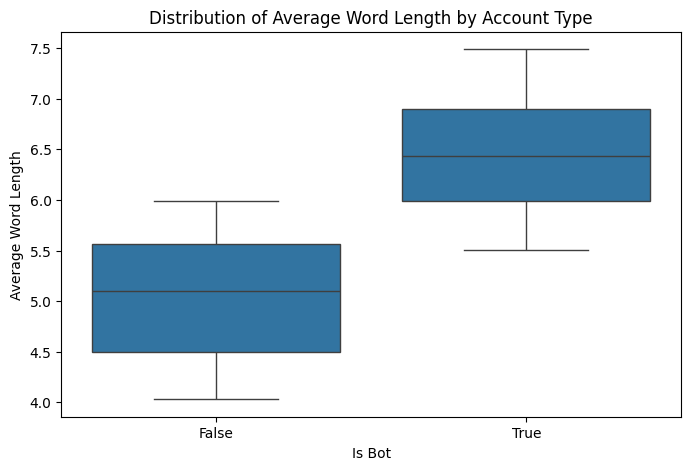

In [ ]:

# --- 1. Comparison of Average Word Length: Humans vs Bots ---
# Visualizing Distribution of Average Word Length
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_bot_flag', y='avg_word_length', data=df_reddit)
plt.title('Distribution of Average Word Length by Account Type')
plt.ylabel('Average Word Length')
plt.xlabel('Is Bot')
plt.show()

**Interpretation of the boxplot:**

The boxplot of average word length reveals a distinct distribution difference between bots and humans. It confirms that bots are consistently more verbose than humans. However, there are several human outliers with very high word counts. This suggests that while bots tend to be more verbose, some humans also write exceptionally long comments, so we cannot simply conclude every time that long comments necessarily mean it is a bot account.

**Exploration of *reply_delay* by account type**


Boxplot of reply delay by account type

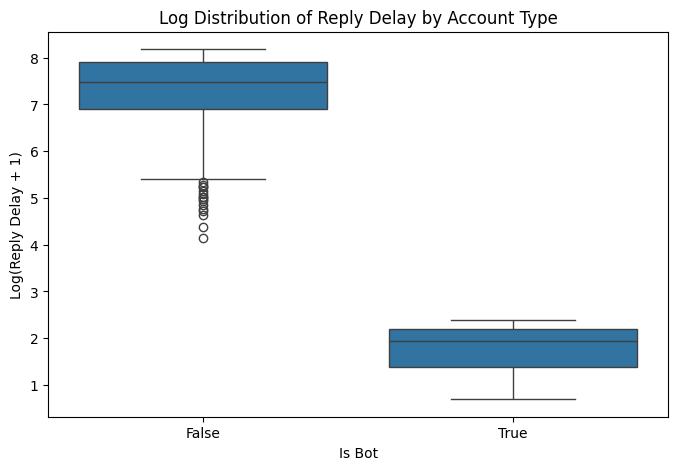

In [ ]:
# Visualizing Probability Distributions (Log-transformed due to heavy right-skew)
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_bot_flag', y=np.log1p(df_reddit['reply_delay_seconds']), data=df_reddit)
plt.title('Log Distribution of Reply Delay by Account Type')
plt.ylabel('Log(Reply Delay + 1)')
plt.xlabel('Is Bot')
plt.show()


**Interpretation of the boxplot:**

Even with a log-transformation for the reply delay, the gap between human and bots reply delay is still very drastic. The median and interquartile range for bots reply delay are substantially lower as compared to that for humans. There are also very few high-end bot outliers, suggesting that the bots in this dataset do not attempt to simluate human-like reading behaviour delays to avoid detection. Hence, we can use fast reponse time as a primary indicator of automation in our predection model.

**Exploration of Feature Correlation and Collinearity**

Check if the numerical metadata actually correlate with the target variable *account_type* and for any collinearity amongst the variables.

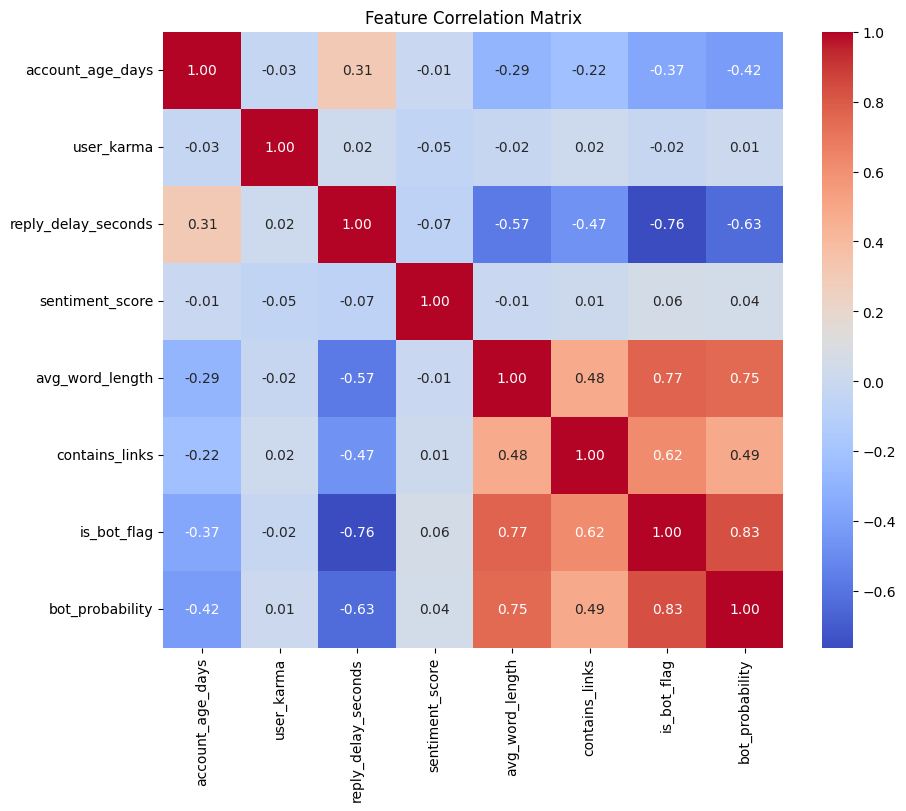

In [ ]:
# Visualizing Feature Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_df = df_reddit.select_dtypes(include=['float64', 'int64', 'bool'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

**Interpretation of the heatmap:**

The correlation heatmap confimrs our above observations and provides a clean summary for the statistical relationship between behavioral markers and the overall bot status.

*avg_word_length* and *contain_links* show a strong positive correlation with $r = 0.77$ and $r = 0.62$ respectively with bot flag, while *reply_delay_seconds* and *account_age_days* show a strong negative correlation with $r = -0.76$ and $r = -0.37$ respectively with bot flag. Meanwhile, the near-zero correlation for *user_karma* ($r \approx 0.01$) proves that bots are successfully camouflaging themselves with human behaviour.

Hence, from our exploration process, the strongest behavioural marker we could use would be *reply_delay_seconds*, *account_age_days*, *average_word_length* and *contains_links*, though some of them have to be scrutinised properly as there are anomalies.

Data Quality Considerations



1. Completeness

The dataset is highly complete with 500 records and zero missing or NULL values across all 11 columns. There is also quite an even distribution between human and bot interaction, which minimises the risk of the model developing a majority-class bias.

2. Accuracy

The dataset does not explain how the data is derived. Hence, we cannot be certain with its accuracy.

3. Reputation

The dataset is not from a known reputable source and we also cannot accertain its reputation.

3. Relevancy and Interpretability

The dataset is relevant, as it contains both behaviourial metrics and account metadata. The inclusion of bot labels also allow for a more granular interpretation of automation beyond a simple binary flag.




**Conclusion for Dataset**

In light of our exploration, we have decided to disregard this Reddit dataset from further consideration in this project. While the data is well-structured and easy to interpret, it fails to meet our requirements for a robust machine learning task for the following reasons:

* Insufficient Dimensionality: With only 11 columns, the dataset is too narrow. After removing identifiers like *comment_id* and the target variables, we are left with very few features. A high-performing model should ideally account for more diverse metadata.

* Small Sample Size: A total of 500 records is insufficient for training a deep or highly generalised model. Splitting this into training and testing sets would leave us with too small a validation pool to prove our model's effectiveness against varied bot behaviors.


Ultimately, we believe that choosing a larger, more complex dataset will enable us to build a better trained model for our project.

### Dataset 2: Twitter Human Bots dataset



**Description**

This dataset contains account-level metadata from Twitter designed to distinguish between human-operated and automated bot accounts based on observable behavioural and structural characteristics. Rather than focusing on tweet content, the dataset emphasises activity patterns and profile attributes, which are commonly used in bot detection research due to their stability and interpretability.

The following code imports the dataset into a data frame and displays the first few rows.

In [ ]:
df_twitter = pd.read_csv('twitter_human_bots_dataset.csv')
print(df_twitter.head())


   Unnamed: 0  ... split
0           0  ...     0
1           1  ...     0
2           2  ...     0
3           3  ...     0
4           4  ...     0

[5 rows x 23 columns]


**Exploration of Dataset Columns**

The following code displays all columns of the data frame and checks for any columns containing missing or NULL values.

In [ ]:
print(df_twitter.columns)
num_rows = df_twitter.shape[0]
print(f"Number of rows: {num_rows}")
print(f"This dataset contains missing/NULL values: {df_twitter.isnull().any().any()}")
missing_columns = df_twitter.columns[df_twitter.isnull().any()].tolist()
print(f"Columns with missing values: {missing_columns}")


print("\n--- Missing Values ---")
missing_data = df_twitter.isnull().sum()
print(missing_data[missing_data > 0])

Index(['Unnamed: 0', 'created_at', 'default_profile', 'default_profile_image',
       'description', 'favourites_count', 'followers_count', 'friends_count',
       'geo_enabled', 'id', 'lang', 'location', 'profile_background_image_url',
       'profile_image_url', 'screen_name', 'statuses_count', 'verified',
       'average_tweets_per_day', 'account_age_days', 'account_type',
       'profile_image_path', 'profile_background_image_path', 'split'],
      dtype='object')
Number of rows: 37438
This dataset contains missing/NULL values: True
Columns with missing values: ['description', 'lang', 'location', 'profile_background_image_url', 'profile_image_url', 'profile_image_path', 'profile_background_image_path']

--- Missing Values ---
description                       7257
lang                              7957
location                             4
profile_background_image_url      4499
profile_image_url                    1
profile_image_path               12938
profile_background_image_p

We can see that the dataset contains missing values in columns, such as description, lang, profile background image and profile image. This is due to some users not having an image or description in their profile etc.

We further examine the data types of each column within the data frame.

In [ ]:
# Print data types of each column
print(df_twitter.dtypes)

Unnamed: 0                         int64
created_at                        object
default_profile                     bool
default_profile_image               bool
description                       object
favourites_count                   int64
followers_count                    int64
friends_count                      int64
geo_enabled                         bool
id                                 int64
lang                              object
location                          object
profile_background_image_url      object
profile_image_url                 object
screen_name                       object
statuses_count                     int64
verified                            bool
average_tweets_per_day           float64
account_age_days                   int64
account_type                      object
profile_image_path                object
profile_background_image_path     object
split                              int64
dtype: object


Excluding the target column *account_type*, the columns of this dataset can be split three types:

Boolean flags (*default_profile*, *default_profile_image*, *geo_enabled*, *verfied*)

Numerical data (*followers_count*, *friends_count*, *favourites_count*, *statuses_count*, *account_age_days*)

Categorical/text data (*lang*, *description*, *location*)


**Exploration of Features Relevance**

The following code helps check for zero-variance columns, where every column has the same value, and extremely high-cardinality columns, such as unique account IDS. These columns lack predictive power and is irrelevant in our analysis.

In [ ]:
total_rows = len(df_twitter)

# calculate the number of unique values for each column
nunique_counts = df_twitter.nunique()

# check for zero-variance columns
zero_variance_cols = nunique_counts[nunique_counts <= 1].index.tolist()
print("--- Zero-Variance Columns ---")
print(zero_variance_cols)

# check for extremely high-cardinality columns
high_cardinality_cols = nunique_counts[nunique_counts == total_rows].index.tolist()
print("\n--- Extremely High-Cardinality Columns ---")
print(high_cardinality_cols)

--- Zero-Variance Columns ---
[]

--- Extremely High-Cardinality Columns ---
['Unnamed: 0', 'id', 'screen_name']


The unamed columns of numbers for each row, *id* and *screen_name* were identified as extremely high-cardinality columns and can be dropped during our subsequent data structuring step.

**Exploration of Target Class Distribution**

Checking target class distribution *account_type* to establish baseline probabilities

The output indicates the number of human and bot account counts and the relative proportion of each class

In [ ]:
# Target Variable Distribution
print("--- Class Distribution ---")
class_counts = df_twitter['account_type'].value_counts()
print(class_counts)
print(df_twitter['account_type'].value_counts(normalize=True) * 100)



--- Class Distribution ---
account_type
human    25013
bot      12425
Name: count, dtype: int64
account_type
human    66.811796
bot      33.188204
Name: proportion, dtype: float64


We can see that from the dataset approximately 66.8% of accounts are human while 33.2% are bots.

**Exploration of Numerical Summary**

Numerical summary for the numerical metadata

In [ ]:
# Descriptive Statistics for Numerical Metadata
num_features = ['followers_count', 'friends_count', 'favourites_count', 'statuses_count', 'account_age_days']
print("\n--- Numerical Summary (Median: Human vs Bot) ---")
print(df_twitter.groupby('account_type')[num_features].median())


--- Numerical Summary (Median: Human vs Bot) ---
              followers_count  friends_count  ...  statuses_count  account_age_days
account_type                                  ...                                  
bot                      25.0           31.0  ...          2178.0            2882.0
human                  1046.0          474.0  ...          7551.0            3395.0

[2 rows x 5 columns]


The median of all of the following numerical metadata is significantly lower for bots than humans. This can interpreted as bots accounts struggling to accumulate more followers, friends and favourites compared to human accounts.

**Exploration of *follower_counts* by account type**

Boxplot of log distribution of followers count by account type

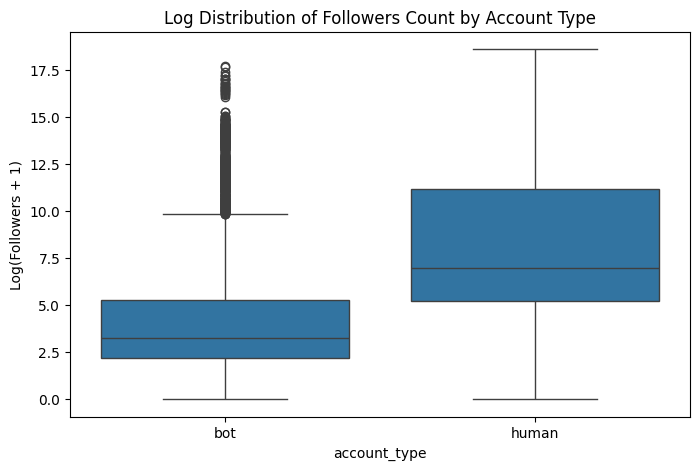

In [ ]:
# Visualizing Probability Distributions (Log-transformed due to heavy right-skew)
plt.figure(figsize=(8, 5))
sns.boxplot(x='account_type', y=np.log1p(df_twitter['followers_count']), data=df_twitter)
plt.title('Log Distribution of Followers Count by Account Type')
plt.ylabel('Log(Followers + 1)')
plt.show()

**Interpretation of the boxplot**

The log-transformed boxplot of follower counts reveals a distinct distribution difference between bots and humans.  

The median and interquartile range for bots are substantially lower than for humans. This suggests that the typical bot accounts struggle to gain more followers.

This clear separation is strong evidence that *followers_count* will be an effective, discriminative feature of our model.

There is also many high-end bot outliers. This suggest numerous bots have managed to artificially inflate their follower counts.

This implies that we cannot simply apply the rule of "high followers = humans" in our prediction model.



**Exploration of Feature Correlation and Collinearity**

Check if the numerical metadata actually correlate with the target variable *account_type* and for any collinearity amongst the variables.

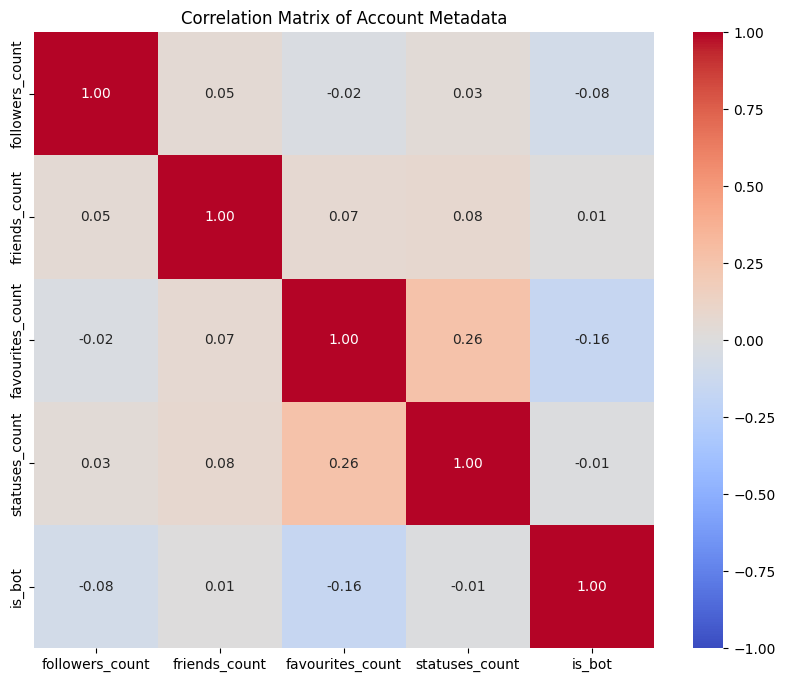

In [ ]:
# Convert target to binary for correlation math (Bot = 1, Human = 0)
df_twitter['is_bot'] = (df_twitter['account_type'] == 'bot').astype(int)

# Select numerical features
num_features = ['followers_count', 'friends_count', 'favourites_count', 'statuses_count', 'is_bot']
corr_matrix = df_twitter[num_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Account Metadata')
plt.show()

**Interpretation of the heat map**

It reveals relatively weak linear relationships between the numerical metadata and whether *account_type* is bot.

This indicates that no single metadata feature can linearly separate humans from bots.

Low feature-to-feature correlation indicates an absence of multicollinearity.

Moreover, there is near zero correlation between *friends_count* and *statuses_count* to *account_type*.

This is important insight that shifts our focus to *followers_count* and *favourites_count* which have higher correlation values.

The dataset likely contains complex, non-linear boundaries such as bots occupying both extreme high and low follower counts. This dataset is better suited for non-linear, tree-based classification algorithms rather than linear regression models.

*Data Quality Consideration*

1. Completeness

The presence of core structural metadata and boolean flags demostrate high completeness. Moreover, there is a good class balance and target veracity with approximately 2:1 ratio of humans and bots. Thus, the dataset is well balanced and suitable for use in model training. Missing values in the dataset can be cleaned off as they are mostly in the irrelevant columns that will not be used in our analysis. Further elaboration will be in data cleaning section.

2. Accuracy

Our analysis relies on the *account_type*. The accuracy of our analysis depends on the accuracy of the labelling of the accounts in this dataset.

3. Reputation

The sources of the data within this dataset is not specified and unknown.

4. Relevancy and Interpretability

The dataset contains relevant account metadata that is highly relevant to our analysis. Additionally, the columns of the dataset are clearly labelled with clear, physical meanings. This allows for clear interpretation of each column.




**Conclusion for Twitter Human Bots Dataset**

In light of the above data exploration, we consider the dataset suited for our analysis with the following caveats, which we will keep in mind during data preparation and analysis:

* The dataset contains many null values and additional irrelevant columns that has to be cleaned off or converted to a binary flag during the data cleaning phase.

* The dataset demostrates weak linear relationships, indicating that we cannot employ linear regression models for this dataset.

### Dataset 3: Bots vs Users dataset



**Description**

The dataset bots_vs_users.csv contains detailed profile metadata and behavioral metrics for 5,874 accounts on a social networking platform. This dataset is specifically designed for the classification task of distinguishing between human-operated accounts and automated bots. The data includes 60 attributes mapping to several key categories:
* Profile Identity: *has_photo, has_birth_date, gender, has_name*
* Privacy & Access: *is_profile_closed, can_send_message, access_to_closed_profile*
* Engagement Metrics: *posts_count, avg_likes, subscribers_count, reposts_ratio*
* Behavioral Content: *avg_text_length, avg_keywords, hashtags_ratio, links_ratio*


The following code imports the dataset into a data frame and displays the first few rows.

In [ ]:
df_botsvsusers = pd.read_csv('bots_vs_users.csv')
print(df_botsvsusers.head)

<bound method NDFrame.head of      has_domain has_birth_date  ... occupation_type_work has_personal_data
0           1.0            1.0  ...              Unknown           Unknown
1           1.0            1.0  ...              Unknown           Unknown
2           1.0            1.0  ...              Unknown           Unknown
3           1.0            1.0  ...              Unknown           Unknown
4           1.0            1.0  ...              Unknown           Unknown
...         ...            ...  ...                  ...               ...
5869        1.0            1.0  ...                  1.0           Unknown
5870        1.0        Unknown  ...                  0.0           Unknown
5871        1.0            1.0  ...                  0.0           Unknown
5872        1.0            1.0  ...                  1.0           Unknown
5873        1.0            1.0  ...                  1.0               1.0

[5874 rows x 60 columns]>


**Exploration of Dataset Columns**


The following code displays all columns of the data frame and checks for any columns containing missing or NULL values.

In [ ]:
print(df_botsvsusers.columns)
num_rows = df_botsvsusers.shape[0]
print(f"Number of rows: {num_rows}")
print(f"This dataset contains missing/NULL values: {df_botsvsusers.isnull().any().any()}")
missing_columns = df_botsvsusers.columns[df_botsvsusers.isnull().any()].tolist()
print(f"Columns with missing values: {missing_columns}")

Index(['has_domain', 'has_birth_date', 'has_photo', 'can_post_on_wall',
       'can_send_message', 'has_website', 'gender', 'has_short_name',
       'has_first_name', 'has_last_name', 'access_to_closed_profile',
       'is_profile_closed', 'target', 'has_nickname', 'has_maiden_name',
       'has_mobile', 'all_posts_visible', 'audio_available', 'has_interests',
       'has_books', 'has_tv', 'has_quotes', 'has_about', 'has_games',
       'has_movies', 'has_activities', 'has_music', 'can_add_as_friend',
       'can_invite_to_group', 'subscribers_count', 'is_blacklisted',
       'has_career', 'has_military_service', 'has_hometown', 'marital_status',
       'has_universities', 'has_schools', 'has_relatives', 'is_verified',
       'is_confirmed', 'has_status', 'posts_count', 'avg_likes', 'links_ratio',
       'hashtags_ratio', 'avg_keywords', 'avg_text_length',
       'attachments_ratio', 'avg_comments', 'reposts_ratio', 'ads_ratio',
       'avg_views', 'posting_frequency_days', 'phone_numbe

**Exploration of Dataset Columns and Sparsity**

The following code assesses the scale of the dataset and the prevalence of missing information, noting that the dataset uses both NaN and the string "Unknown" to represent missing data.

Number of rows: 5874
Number of columns: 60

--- Top Features with Missing Data (Counts) ---
has_personal_data             5006
has_movies                    4601
has_books                     4601
has_activities                4601
has_tv                        4601
has_quotes                    4601
has_about                     4601
has_games                     4601
has_interests                 4601
has_hometown                  4601
has_career                    4601
has_music                     4601
has_military_service          4601
has_relatives                 4601
has_schools                   4601
has_universities              4601
marital_status                4601
reposts_ratio                 4483
posts_count                   4483
links_ratio                   4483
avg_likes                     4483
hashtags_ratio                4483
avg_text_length               4483
avg_keywords                  4483
avg_comments                  4483
avg_text_uniqueness           448

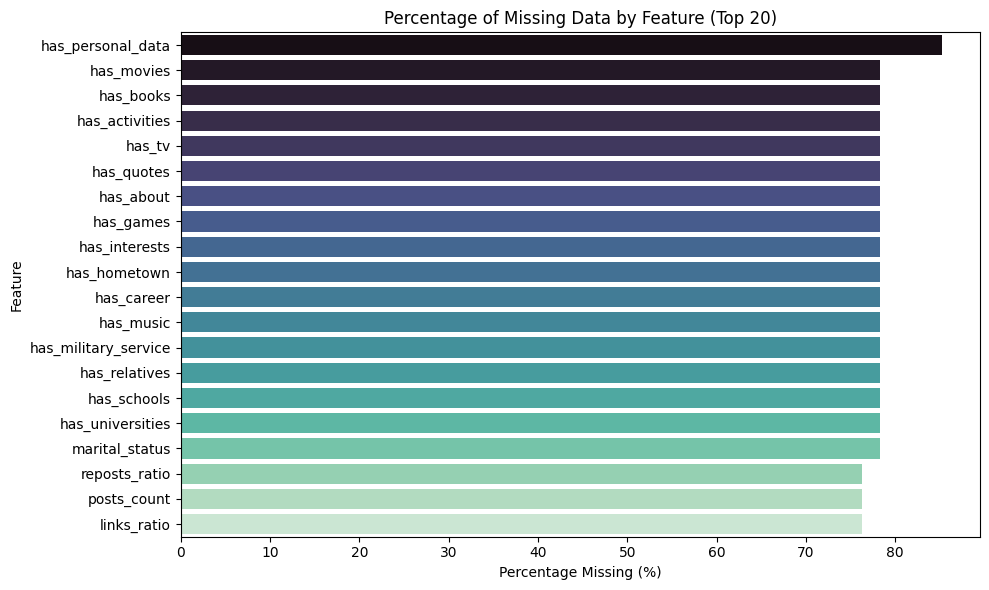

In [ ]:

df_clean = df_botsvsusers.replace('Unknown', np.nan)

# Convert behavioral columns to numeric (force strings to NaN)
numeric_cols = ['posts_count', 'avg_likes', 'subscribers_count', 'avg_text_length', 'reposts_ratio']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# DATASET OVERVIEW
num_rows, num_cols = df_clean.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

# MISSING VALUE ANALYSIS (Table + Plot)
# both the table and plot use df_clean.isnull()
missing_counts = df_clean.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df_clean) * 100)

print("\n--- Top Features with Missing Data (Counts) ---")
print(missing_counts.head(60))

# Plotting the Percentages
plt.figure(figsize=(10, 6))
# We use head(20) for the plot to keep it readable
sns.barplot(x=missing_percent.head(20).values, y=missing_percent.head(20).index, hue=missing_percent.head(20).index, palette="mako", legend = False)
plt.title('Percentage of Missing Data by Feature (Top 20)')
plt.xlabel('Percentage Missing (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Interpretation of Sparsity and Data Density Results**

The analysis of missing and "Unknown" values across the 60 attributes of the bots_vs_users.csv dataset reveals critical insights into the quality and structure of the data:

* We found extreme sparsity in personal fields such as *has_personal_data* (5,006 missing) and various interest flags like *has_movies, has_books, and has_activities* (4,601 missing). Since these fields exhibit a missing rate of around 78\% - 85\%, it suggests that these fields are purely optional profile components that the vast majority of users (both human and bot) choose not to fill in. From a machine learning perspective, these features may provide very little signal and could potentially be dropped to reduce the dimensionality of the model.

* There is a gap in behavioral metrices since there is a consistent block of 4,483 missing values (approx. 76\%) for activity-based features such as *posts_count, avg_likes, reposts_ratio, and avg_text_length*. This indicates a "data cliff" as while we have profile metadata for 5,874 accounts, we only have actual behavioral/posting data for about 1,391 of them. This suggests that a large portion of the accounts in the dataset are either empty profiles (lurkers/newly created bots) or have privacy settings that blocked the collection of activity metrics.

* In contrast, the core metadata features like *has_domain, has_photo, has_first_name*, and *gender* are nearly 100\% complete, with only 24 missing values (< 0.5\%). These represent the identity baseline of the dataset since these fields are consistently filled, and they will likely serve as the primary features for the initial classification model.

* It is interesting that many features share identical counts of missing values (e.g., 2,556 or 4,601), which suggests that the data was likely collected in batches or modules. For example, if a scraper couldn't access an account's "Interests" section, it probably marked every sub-field (books, music, tv) as "Unknown" simultaneously.

* The target variable has 0 missing values. This confirms that the ground truth labels are fully intact for all 5,874 records, which is essential for supervised learning.

**Exploration of Target Class Distribution**

We check the target distribution to establish baseline probabilities for human ($0$) and bot ($1$) accounts.

--- Class Distribution ---
target
1    2937
0    2937
Name: count, dtype: int64
target
1    50.0
0    50.0
Name: proportion, dtype: float64


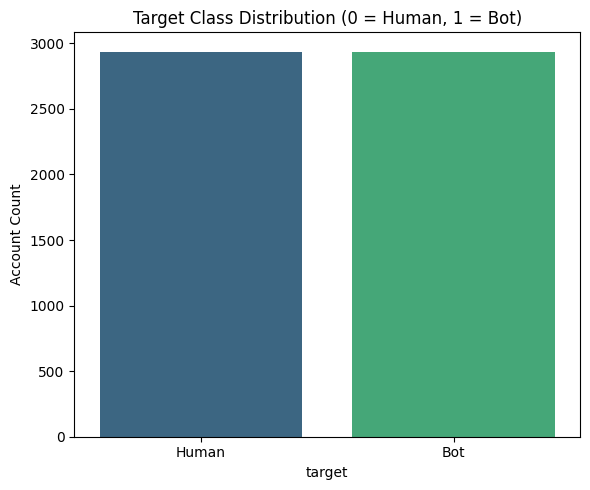

In [ ]:
print("--- Class Distribution ---")
class_counts = df_botsvsusers['target'].value_counts()
print(class_counts)
print(df_botsvsusers['target'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 5))
sns.countplot(data=df_clean, x='target', hue='target', palette="viridis", legend=False)
plt.title('Target Class Distribution (0 = Human, 1 = Bot)')
plt.xticks([0, 1], ['Human', 'Bot'])
plt.ylabel('Account Count')
plt.tight_layout()


Interpretation:

The dataset is perfectly balanced, with exactly 2,937 human accounts and 2,937 bot accounts (50\% each). This lack of class imbalance is ideal for training robust machine learning models without the need for synthetic oversampling.

**Exploration of Geographic Distribution (City)**

To determine if bot activity is localised, we analyse the city attribute.

In [ ]:
# Top 10 Cities in the data
city_stats = df_botsvsusers['city'].value_counts().head(10)
print("--- City Distribution ---")
print(city_stats)

--- City Distribution ---
city
Unknown             2780
Saint Petersburg    1549
Kostomuksha          405
Moscow               335
Petrozavodsk         103
Nizhny Novgorod       18
Yekaterinburg         15
Vladivostok           14
Rostov-on-Don         12
Krasnodar             12
Name: count, dtype: int64


**Interpretation:**

* Concentration of Data: Aside from "Unknown" entries, the data is heavily concentrated in Saint Petersburg (1,549), Kostomuksha (405) and Moscow (335).

* Regional Bias: The high prevalence of Russian cities suggests that the bot behaviors observed here are specific to the VK platform. Any resulting model will be highly specialised for Cyrillic/Russian social media contexts.

**Numerical Summary of Behavioral Contrast**

We investigate the median values for key behavioral metrics like *posts_count, avg_likes, subscribers_count and avg_text_length* to identify distinct separators between humans and bots. We decided to focus on the median to mitigate the effect of extreme outliers in activity counts.

In [ ]:
# Convert Unknown to NaN for calculation
df_clean = df_botsvsusers.replace('Unknown', np.nan)
for col in ['posts_count', 'avg_likes', 'subscribers_count', 'avg_text_length']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Numerical Summary (Median: Human vs Bot)
summary_cols = ['posts_count', 'avg_likes', 'subscribers_count', 'avg_text_length']
print(df_clean.groupby('target')[summary_cols].median())

        posts_count  avg_likes  subscribers_count  avg_text_length
target                                                            
0              20.0      14.75              865.0          195.550
1              20.0       0.00               44.0         1198.275


**Rationale to focus on these specific metrics:**

While our initial sparsity analysis showed a "data cliff" with about 76% missing values for the behavioral metrices, we have decided to prioritise *posts_count, avg_likes, subscribers_count* and *avg_text_length* data fields. Here is the rationale behind our decision:   

* Extreme Sparsity: A lot of columns in *has_books* or *has_military_service* are empty for over 80% of the accounts. Trying to train a model on empty data or values adds more noise rather than accuracy.

* Low Variance: Some of the flags (like *has_domain*) are nearly identical for both bots and human accounts. If a feature doesn't vary between both groups, it can't help the model to distinguish between them.

* Avoiding Redundancy (Multicollinearity): Similar information can be inferred from some of the columns. For example, features like *avg_keywords* and *avg_text_length* are highly correlated. By picking the most representative one (*avg_text_length*), we keep the model efficient without losing any real insight.

* Overfitting Prevention: With only ~5,800 rows, using too many features causes the model to "memorise" specific data quirks rather than learning general patterns. Focusing on high-impact metrics ensures our classifier is robust and the model actually works on new, unseen data.

**Box Plot for Distribution of Average Likes**

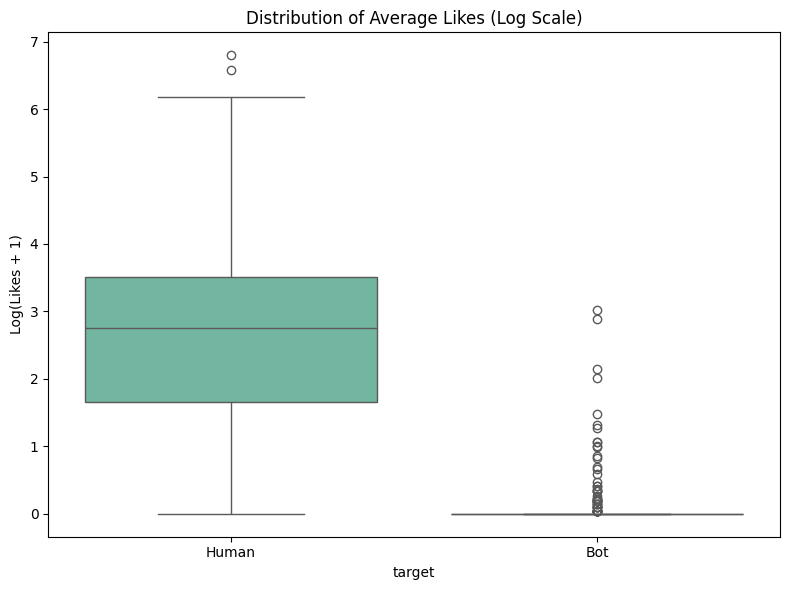

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='target', y=np.log1p(df_clean['avg_likes']), hue='target', palette="Set2", legend=False)
plt.title('Distribution of Average Likes (Log Scale)')
plt.ylabel('Log(Likes + 1)')
plt.xticks([0, 1], ['Human', 'Bot'])
plt.tight_layout()
plt.show()

**Box Plot for Distribution of Subscribers Count**

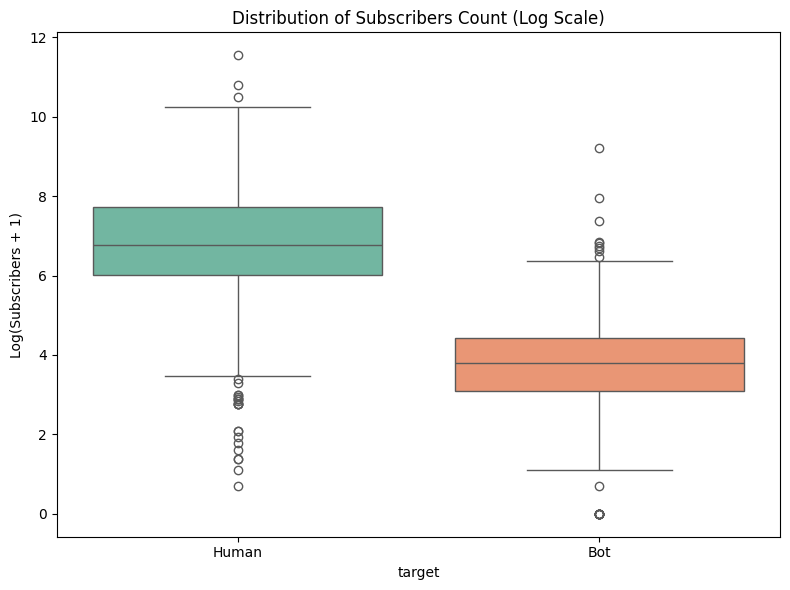

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='target', y=np.log1p(df_clean['subscribers_count']), hue='target', palette="Set2", legend=False)
plt.title('Distribution of Subscribers Count (Log Scale)')
plt.ylabel('Log(Subscribers + 1)')
plt.xticks([0, 1], ['Human', 'Bot'])
plt.tight_layout()
plt.show()

**Box Plot for Distribution of Average Text Length**

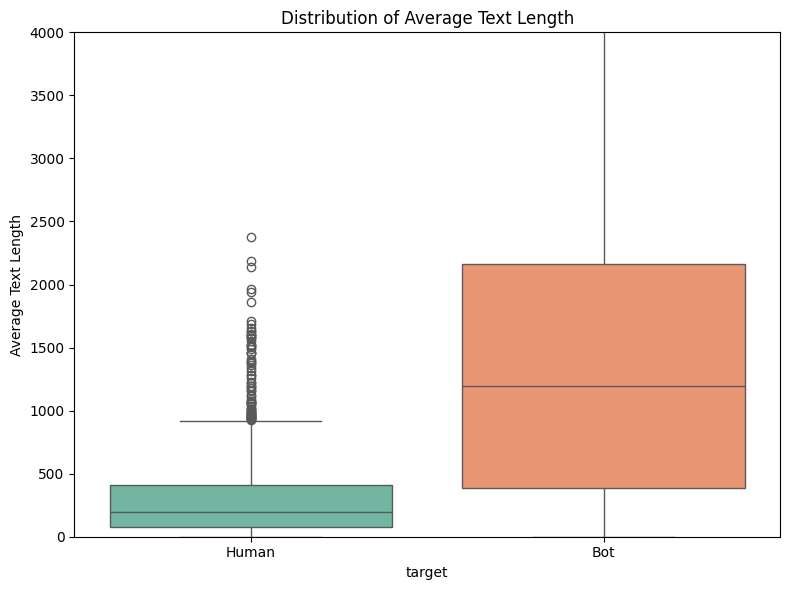

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='target', y='avg_text_length', hue='target', palette="Set2", legend=False)
plt.title('Distribution of Average Text Length')
plt.ylabel('Average Text Length')
plt.ylim(0, 4000)
plt.xticks([0, 1], ['Human', 'Bot'])
plt.tight_layout()
plt.show()

**Interpretation of overall data:**

* Post Count: Surprisingly, the volume of posts is identical for both bots and human accounts with a median of 20 posts. This suggests that bots in this sample are not just spamming posts but are programmed to mimic a human bevaviour level of activity, so relying on post count quantity is a poor predictor of bot accounts.

* Average Likes: From our data, human accounts have a median of approximately 15 likes, but bots on the other hand are posting into a void with a median of 0 likes. This observation is also conclusive from the boxplot, and is generally logical as humans naturally receive social validation in the form of likes from friends and followers. Hence, an account with little to no likes is a huge indicator for an automated account.

* Subscribers Count: We can see that the outreach of human accounts tend to be larger with a median of 865 subscribers, whereas bot accounts are largely isolated with a median of a mere 44 subscribers. Referencing the boxplot, the separation is extremely clear as it shows that most human accounts sit comfortably in the upper brackets, while the bot account distribution is heavily weighted towards the bottom. This conclusion is logical as humans tend to build networks and connections over time, so having a larger subscriber/follower base is valid. Bot accounts on the other hand are often throwaway accounts with very little social reach beyond other automated accounts or accidental followers. Hence, if an account is posting content but with minimal subscribers/followers, it is a tell-tale sign that the account is likely a bot account.

* Text Length: Human accounts have an average text length of approximately 200 words, while bot accounts have an average text length of approximately 1200 words. This suggests that humans prefer to be brief and concise when they are typing, and it is rational as human-beings tend to use slang or shortforms when typing. It also means that bots tend to be overly formal, structured and long-winded. However, from the box plot, there are several human outliers with very high word counts. This suggests that while bots tend to be more verbose, some humans also write exceptionally long comments, so we cannot simply conclude every time that long comments necessarily mean it is a bot account.

**Distribution of Profile Completeness Score**

One of the most effective ways to identify automated agents is by looking at the effort invested in account setup. We developed a "Completeness Score" by aggregating various profile metadata flags (such as the presence of a photo, birth date, status, and career information).

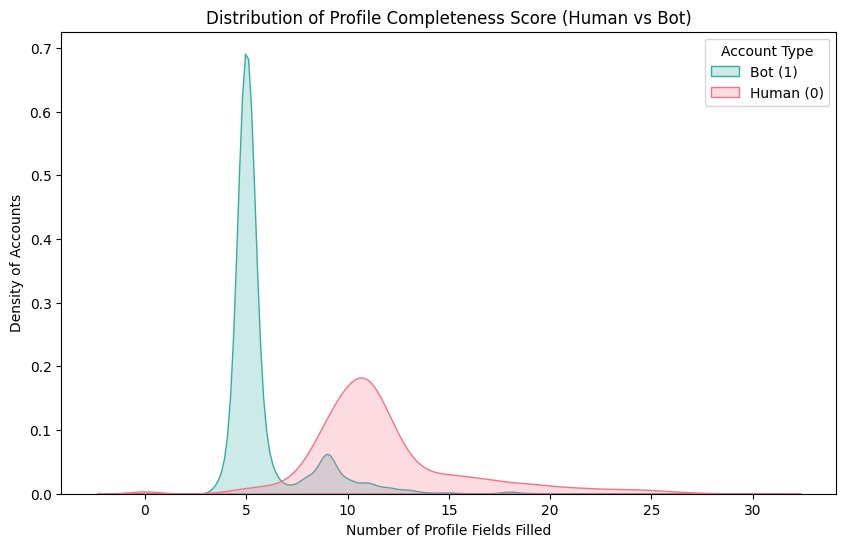

In [ ]:
# Identify profile columns (those starting with 'has_', 'is_', or 'can_')
profile_flags = [c for c in df_clean.columns if c.startswith(('has_', 'is_', 'can_'))]

# Convert flags to numeric and fill missing with 0
# We use .apply(pd.to_numeric) to ensure no strings remain
df_clean['completeness_score'] = (df_clean[profile_flags].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1))

# Plot Distribution of Completeness (Density Plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_clean, x='completeness_score', hue='target', fill=True, palette="husl", common_norm=False)
plt.title('Distribution of Profile Completeness Score (Human vs Bot)')
plt.xlabel('Number of Profile Fields Filled')
plt.ylabel('Density of Accounts')
plt.legend(title='Account Type', labels=['Bot (1)', 'Human (0)'])
plt.show()

**Interpretation of data:**

The density plot for automated accounts shows a significant concentration peaking at a score of 5. This suggests that these bot accounts in this dataset are not completely empty, but instead are designed to fill in only the bare minimum number of fields needed to appear legitimate. Rather than developing rich profiles, they are likely programmed to populate a small, fixed set of key attributes to mimic a real user and pass the basic platform checks.

In contrast, human accounts show a much broader distribution that peaks significantly higher, around a score of 10. This reflects the more organic and cumulative nature of human behaviour. While a bot stops once it has fulfilled its minimum threshold for appearing credible, real users continue to build on their profiles over time, adding new information as their lives evolve.

The most useful finding for classification is the separation beyond the bot peak and human account. While there is some overlap between the two groups in the 4 – 7 profile fields filled range, the probability of an account being a bot decreases sharply once it hits double digits for the number of profile fields filled. Hence, this confirms that while bots can be programmed to meet a baseline number of attributes to fill in, they rarely reach the double-digit level of detail that characterises an active, long-term human user.

**Data Quality Considerations**

1. Completeness and the "Data Cliff" vs Privacy Bias

The biggest issue in this dataset is the massive gap in behavioral data. While the basic profile info (like having a photo or a name) is almost 100% complete, we hit a "data cliff" with things like avg_likes and posts_count, where about 76% of the rows are empty.

A deeper investigation reveals that this sparsity is not random; it is highly correlated with account privacy. For accounts where is_profile_closed is true, 100% of behavioral data is missing. In this dataset, 24% of human users have closed profiles, whereas only 1.7% of bots use this setting.

* Imputation Strategy: Treating missing engagement as "zero likes" would systematically bias the model against privacy-conscious human users, making them appear bot-like. Instead, we will use indicator variables (e.g., is_behavioral_data_missing) to allow the model to learn that "hidden data" is a human-positive trait in this specific context.

<br>

2. Relevancy and Feature Signal

The dataset contains a mix of high-signal behavioral data and low-signal profile flags.

* Low-Signal Data: Optional fields such as has_books, has_music, or has_quotes are over 80% empty across both classes. These features offer little differentiation and will be pruned to reduce noise and prevent overfitting.

* High-Signal Metrics: Despite the sparsity, features like avg_likes (median 15 for humans vs. 0 for bots) and subscribers_count remain critical separators for public profiles. To maintain signal for private accounts, we rely on the "Completeness Score," which captures the depth of account setup that bots rarely replicate.

<br>

3. Accuracy and Potential Bias

* Platform and Regional Specificity: The heavy concentration of localized data in Russian cities like Saint Petersburg and Moscow indicates that this dataset is specific to the VK platform. Consequently, the model will be highly accurate for Cyrillic/Russian social media contexts, but its findings may not generalize to global platforms like X (Twitter) or LinkedIn, where behavioral norms regarding privacy and text length differ.

* Labeling Circularity: We must acknowledge the risk of "circular reasoning" in how the ground truth labels were generated. If the bots were originally identified by human auditors using visual cues, such as a lack of profile photos or low engagement, the model might simply learn to replicate human stereotypes of bot behavior rather than uncovering genuine, underlying automated patterns. This necessitates caution when interpreting the model’s "discovery" of these same features as predictive.

<br>

**Conclusion for the Bots vs. Users Dataset**

Based on our exploration, we will proceed with the analysis by prioritizing model robustness over aggressive data cleaning, focusing on three key principles:

* Preserving the "Data Cliff": Because missing behavioral data is a strong indicator of a private (and likely human) profile, we will not delete these rows. Instead of simple zero-filling, we will treat "Unknown" as a meaningful category. This ensures the model distinguishes between a bot that has zero engagement and a human whose engagement is simply hidden by privacy settings.

* Feature Pruning for Noise Reduction: We will handle redundant data carefully by removing columns such as has_movies or has_quotes. Since these fields are mostly empty and do not meaningfully differentiate humans from bots, removing them helps reduce noise and prevents the model from identifying random, coincidental patterns that lead to overfitting.

* Capturing Non-Linear Patterns: Since humans and bots overlap in simpler metrics like post counts (both medians are 20), a linear approach would fail. We will utilize tree-based models, such as Random Forest, which are uniquely suited to handle this dataset’s complexity. These models can effectively navigate the necessary "if-then" logic: for example, identifying that zero likes on an open profile suggests a bot, whereas missing likes on a closed profile suggests a human.

<br>

Overall, the dataset provides a strong foundation for classification due to its perfect class balance (1:1 ratio), which eliminates the need for synthetic oversampling. While basic metadata like has_photo is easily manipulated by bot creators, the combination of Behavioral Ratios (likes/subscribers) and our engineered Completeness Score creates a multi-layered defense. The "minimalist bot" pattern, where automated accounts fill only a scripted, bare-minimum set of fields, is clearly visible in the data. By accounting for the nuances of privacy, data sparsity, and regional bias, we can develop a classifier that is both accurate and fair to legitimate users.

### Dataset 4: Twitter Analysis dataset


**Description**

This dataset contains 134,198 Twitter records defined by 62 distinct attributes, providing a robust mix of linguistic features, account metadata, bot detection metrics and engagement statistics. The account-level metadata in the dataset (followers count, friends count, statuses count, listed count) provides structural behavioral signals commonly shown in automated accounts. Furthermore, engagement features such as replies, retweets, and quotes help identify the abnormal interaction patterns typical of bots. Most importantly, the dataset includes a binary bot classification label (BotScoreBinary) which enables supervised learning approaches.



The following code imports the dataset into a data frame and displays the first few rows.

In [ ]:
df_ds4 = pd.read_csv('Twitter Analysis.csv')
print(df_ds4.head(3))

   Unnamed: 0  majority_target  ... long_word_freq  short_word_freq
0           0             True  ...              5               19
1           1             True  ...              2               34
2           2             True  ...              4               10

[3 rows x 64 columns]


**Exploration of NaN values**

The following checks for missing values in the dataset, that would need cleaning.

In [ ]:
# calculate the number of NaN values and percentage for each column
nan_counts = df_ds4.isnull().sum()
total_counts = df_ds4.shape[0]
nan_percentages = (nan_counts / total_counts) * 100

nan_table = pd.DataFrame({'NaN Count': nan_counts, 'NaN Percentage (%)': nan_percentages})

# show the top 10 columns with the highest percentage of missing values
print("--- Missing Values Summary (Top 10) ---")
print(nan_table.sort_values(by='NaN Percentage (%)', ascending=False).head(10))

--- Missing Values Summary (Top 10) ---
                  NaN Count  NaN Percentage (%)
Unnamed: 0                0                 0.0
majority_target           0                 0.0
statement                 0                 0.0
BinaryNumTarget           0                 0.0
tweet                     0                 0.0
followers_count           0                 0.0
friends_count             0                 0.0
favourites_count          0                 0.0
statuses_count            0                 0.0
listed_count              0                 0.0


The dataset has zero missing values across all columns which means we are able to bypass complex imputation steps during data preparation.

**Exploration of Dataset Columns**

We further examine the data types of each column within the data frame.

In [ ]:
print(df_ds4.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134198 entries, 0 to 134197
Data columns (total 64 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Unnamed: 0              134198 non-null  int64  
 1   majority_target         134198 non-null  bool   
 2   statement               134198 non-null  object 
 3   BinaryNumTarget         134198 non-null  float64
 4   tweet                   134198 non-null  object 
 5   followers_count         134198 non-null  float64
 6   friends_count           134198 non-null  float64
 7   favourites_count        134198 non-null  float64
 8   statuses_count          134198 non-null  float64
 9   listed_count            134198 non-null  float64
 10  following               134198 non-null  float64
 11  embeddings              134198 non-null  object 
 12  BotScore                134198 non-null  float64
 13  BotScoreBinary          134198 non-null  float64
 14  cred                

From the data types, we can see there are a few categories

1. Bot classification label & target metrics (BotScoreBinary, BotScore, etc)
2. Account-level metadata (followers_count, friends_count, etc)
3. Engagement features (replies, retweets, etc)
4. Linguistic data (Word count, Average word length, etc)
5. Named entity recognition percentages (ORG_percentage, NORP_percentage)
6. Semantic representations (embeddings)
7. Non-useful data (Unnamed)

**Exploration of Features Relevance**


The following code helps check for zero-variance columns, where every column has the same value, and extremely high-cardinality columns, such as unique account IDS. These columns lack predictive power and is irrevelant in our analysis.

In [ ]:
total_rows = len(df_ds4)

# calculate the number of unique values for each column
nunique_counts = df_ds4.nunique()

# check for zero-variance columns
zero_variance_cols = nunique_counts[nunique_counts <= 1].index.tolist()
print("--- Zero-Variance Columns ---")
print(zero_variance_cols)

# check for extremely high-cardinality columns
high_cardinality_cols = nunique_counts[nunique_counts == total_rows].index.tolist()
print("\n--- Extremely High-Cardinality Columns ---")
print(high_cardinality_cols)


--- Zero-Variance Columns ---
['following']

--- Extremely High-Cardinality Columns ---
['Unnamed: 0', 'tweet']


From this and the previous exploration, we can see the data that is not relevant is as such:
1. Unnamed: 0 (No semantic meaning)
2. following (All values are zeros)
3. tweet (String columns that cannot be used directly)
4. statement (String columns that cannot be used directly)
5. embeddings (Complex parsing needed to make it usable)
6. BotScore (Already have BotScoreBinary to teach model on Bot accounts)

**Exploration of Target Class Distribution**

Analyse the target variable: BotScoreBinary to see the distribution of Human and Bot accounts in the dataset.

--- Class Distribution (BotScoreBinary) ---
BotScoreBinary
0.0    129856
1.0      4342
Name: count, dtype: int64
Humans: 96.8%
Bots: 3.2%


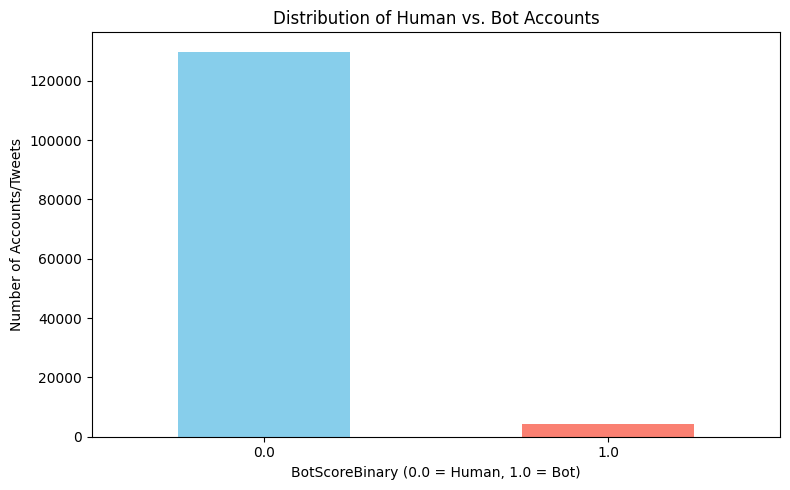

In [ ]:
# check the distribution of the target variable (Bot vs. Human)
bot_counts = df_ds4['BotScoreBinary'].value_counts(dropna=False)
print("--- Class Distribution (BotScoreBinary) ---")
print(bot_counts)
total = bot_counts.sum()
print("Humans: " + str((bot_counts[0]/total).round(3)*100)+ "%")
print("Bots: "+ str((bot_counts[1]/total).round(3)*100)+ "%")

# visualize the class imbalance
plt.figure(figsize=(8, 5))
bot_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.xlabel('BotScoreBinary (0.0 = Human, 1.0 = Bot)')
plt.ylabel('Number of Accounts/Tweets')
plt.title('Distribution of Human vs. Bot Accounts')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The distribution chart shows a severe class imbalance. The dataset consists of a majority of human accounts at 96.8% with bot accounts representing only a small fraction of 3.2%.

**Exploration of Feature Correlation and Collinearity**

The following utilises a correlation heatmap to quantitatively assess the linear relationships between our features and the BotScoreBinary target.

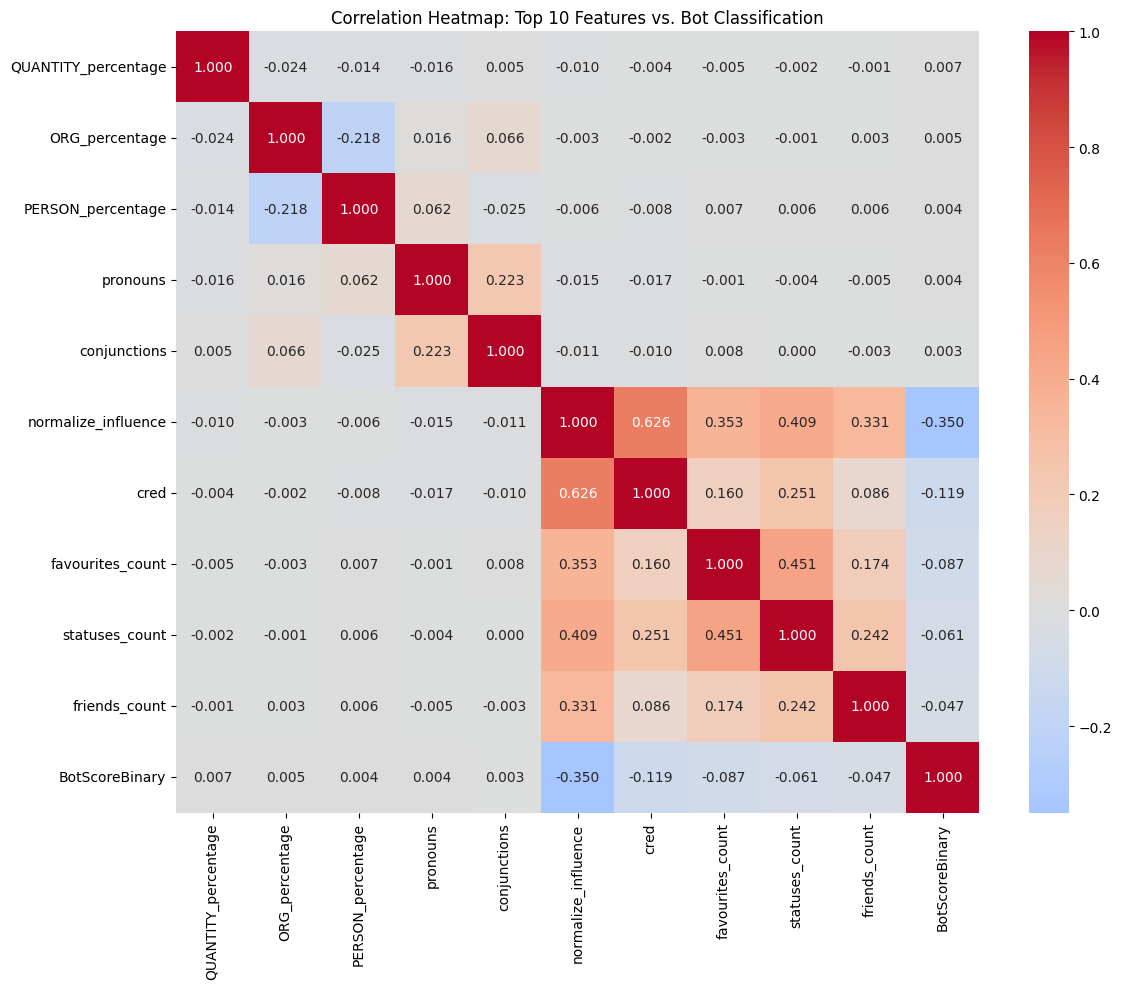

--- Strongest Positive Correlations (Bot-Like Traits) ---
QUANTITY_percentage    0.007257
ORG_percentage         0.004931
PERSON_percentage      0.003804
pronouns               0.003523
conjunctions           0.002589
Name: BotScoreBinary, dtype: float64

--- Strongest Negative Correlations (Human-Like Traits) ---
normalize_influence   -0.349786
cred                  -0.119437
favourites_count      -0.086887
statuses_count        -0.061007
friends_count         -0.046619
Name: BotScoreBinary, dtype: float64


In [ ]:
# drop non-numerical columns and data leakage columns in comparisons
cols_to_drop = [
    'Unnamed: 0', 'following', 'tweet', 'statement',
    'BotScore',  'embeddings'
]
num_df = df_ds4.drop(columns=cols_to_drop, errors='ignore')

# get correlations specifically with the target variable (BotScoreBinary)
correlations = num_df.corr()['BotScoreBinary'].drop('BotScoreBinary')

# select the top 5 positively correlated and top 5 negatively correlated features
top_positive = correlations.nlargest(5).index.tolist()
top_negative = correlations.nsmallest(5).index.tolist()

# combine them with the target to create our final list of features
best_features = top_positive + top_negative + ['BotScoreBinary']

# plot
plt.figure(figsize=(12, 10))
sns.heatmap(num_df[best_features].corr(), annot=True, cmap='coolwarm', fmt=".3f", center=0)
plt.title('Correlation Heatmap: Top 10 Features vs. Bot Classification')
plt.tight_layout()
plt.savefig('top_features_heatmap.png')
plt.show()

print("--- Strongest Positive Correlations (Bot-Like Traits) ---")
print(correlations.nlargest(5))
print("\n--- Strongest Negative Correlations (Human-Like Traits) ---")
print(correlations.nsmallest(5))

From this heatmap, it shows the strongest negative correlations (human-like traits) such as normalize_influence and cred showing that human accounts possess significantly higher influence ratios and baseline credibility than bot accounts.

Furthermore, it also shows the strongest positive correlations such as QUANTITY_percentage and ORG_percentage. Though the values are small, it shows bots use distinct syntax and rely more on specific named entities and rigid grammatical structures than humans.

*Data Quality Considerations*

1. Completeness




* The data is complete, featuring a wide variety of 62 attributes ranging from account-level metadata to linguistic features. The profiling confirmed that there were 0% missing values across all columns which eliminates the need for complex imputation.

2. Accuracy

* Our analysis would rely on the BotScoreBinary which the dataset does not explain how the labels were generated.. This could be a potential source of bias which if original labels were inaccurate would result in our models being less accurate as well. In addition, with bot tactics changing rapidly, the patterns in this dataset may need frequent updates to counter newer automated accounts.

3. Reputation

* This dataset is taken from Kaggle in which it was referenced from CIC Truth Seeker Dataset 2023. The Canadian Institute for Cybersecurity is highly regarded in the field of network and data security. Therefore, the dataset is highly reputable.

4. Relevancy and Interpretability

* The features are mostly clearly labelled with clear, physical meanings. This allows us to be able to explain why an account was flagged as a bot.


**Conclusion for Twitter Analysis Dataset**

In light of the above data exploration, we consider the dataset suited for our analysis with the following caveats, which we will keep in mind during data preparation and analysis:

* Since bots are rare in this dataset, we will need to ensure the model does not simply ignore them in favour of the human data.
* Removing of the 6 irrelevant or redundant columns identified during the exploration.



### Dataset Selection

From our data exploration, we have decided to retain Datasets 2, 3 and 4 for our analysis while droping Dataset 1.



## **Data Preparation (Process)**

### Dataset 2

**Data Structuring for Dataset 2**

While numerical metadata is 100% complete, text field likes *description* and *location* contains significant missing values.

We will drop the extremely high cardinality columns identified earlier.

In [ ]:
total_rows = len(df_twitter)

# calculate the number of unique values for each column
nunique_counts = df_twitter.nunique()

# check for zero-variance columns
zero_variance_cols = nunique_counts[nunique_counts <= 1].index.tolist()
print("--- Zero-Variance Columns ---")
print(zero_variance_cols)

# check for extremely high-cardinality columns
high_cardinality_cols = nunique_counts[nunique_counts == total_rows].index.tolist()
print("\n--- Extremely High-Cardinality Columns ---")
print(high_cardinality_cols)

--- Zero-Variance Columns ---
[]

--- Extremely High-Cardinality Columns ---
['Unnamed: 0', 'id', 'screen_name']


In [ ]:
columns_to_drop = high_cardinality_cols

# drop them directly from the dataframe
df_twitter.drop(columns=[c for c in columns_to_drop if c in df_twitter.columns], inplace=True)



**Data Enriching**

Adding network ratios *network_ratio*, which is the ratio of followers to friends, to capture the classic bot behaviour of mass-following accounts without gaining followers in return

In [ ]:
df_twitter['network_ratio'] = df_twitter['followers_count'] / (df_twitter['friends_count'] + 1) # +1 prevents division by zero

Since bots often have empty profile bios, the *description* column contains many missing values. We can create a binary flag *has_description* to tackle this.

In [ ]:
df_twitter['has_description'] = df_twitter['description'].notna().astype(int)

**Data Cleaning**

The creation of the binary flag *has_description* effectively cleans the dataset of the null values in the *description* column. Hence, we can drop the *description* column entirely.

We will drop additional columns that are irrelevant or unuseable in the scope of our analysis.

This includes *location*, *profile_image_url*, *profile_background_image_url*, *profile_image_path*,*profile_background_image_path*. Image analysis requires computer vision and is beyond the scope of our project

In [ ]:
# Manually drop columns irrelevant
manual_drops = ['description', 'location', 'profile_image_url', 'profile_background_image_url', 'profile_image_path', 'profile_background_image_path']
df_twitter = df_twitter.drop(columns=manual_drops)
print(f"Cleaned dataset shape: {df_twitter.shape}")


Cleaned dataset shape: (37438, 17)


### Dataset 3

Data Structuring for Dataset 3

Before training, we must identify columns that provide no predictive power, specifically "Zero-Variance" columns (where every account has the same value) and "High-Cardinality" columns (unique identifiers).

In [ ]:
# Calculate unique values after replacing 'Unknown' with NaN
df_clean = df_botsvsusers.replace('Unknown', np.nan)
nunique_counts = df_clean.nunique()

# Check for Zero-Variance (No difference between any users)
zero_variance_cols = nunique_counts[nunique_counts <= 1].index.tolist()
print(f"--- Zero-Variance Columns to Drop: {zero_variance_cols} ---")

# Check for High-Cardinality (Unique identifiers)
high_cardinality_cols = nunique_counts[nunique_counts >= len(df_clean) * 0.9].index.tolist()
print(f"--- High-Cardinality Columns: {high_cardinality_cols} ---")

# Drop the non-informative columns
df_clean = df_clean.drop(columns=zero_variance_cols + high_cardinality_cols)

--- Zero-Variance Columns to Drop: ['has_domain', 'has_birth_date', 'has_short_name', 'has_first_name', 'is_blacklisted', 'has_occupation', 'has_personal_data'] ---
--- High-Cardinality Columns: [] ---


Result: We identified several zero-variance columns (e.g., has_domain, has_birth_date, is_blacklisted) that do not help with classification and have been removed to streamline the model.

Data Enriching

To capture the "Minimalist Bot" behavior and account for the privacy-induced data gaps, we have added two critical features:

In [ ]:
# 1. Completeness Score: Aggregates profile flags to measure account detail
profile_flags = [c for c in df_clean.columns if c.startswith(('has_', 'is_', 'can_'))]
df_clean['completeness_score'] = (df_clean[profile_flags]
                                  .apply(pd.to_numeric, errors='coerce')
                                  .fillna(0).sum(axis=1))

# 2. Behavioral Visibility Flag: Turns the 'Data Cliff' into a feature
# This helps the model distinguish between hidden data (Privacy) and no data (Bot activity)
df_clean['has_behavioral_data'] = df_clean['posts_count'].notnull().astype(int)

Data Cleaning

We will handle the 76% missing behavioral data by acknowledging its relationship with privacy, rather than using naive imputation.

* Dropping Sparse Interests: We drop columns like has_movies, has_books, and has_military_service. These fields are over 80% empty and add more noise than accuracy to the model.

* Handling Behavioral Metrics (The Data Cliff): We will not fill missing values for metrics like avg_likes or avg_text_length with zero.

  * Logic: Since 100% of closed (private) profiles are missing this data, and most private profiles are humans, filling with zero would create a systematic bias, making private humans look like inactive bots.

  * Strategy: We keep these as NaN. By using tree-based models (like Random Forests), the model can learn that NaN on a private profile is a "human" signal, while 0 on an open profile is a "bot" signal.

In [ ]:
# 1. Drop low-signal interest columns
sparse_interests = ['has_movies', 'has_books', 'has_tv', 'has_games', 'has_quotes',
                    'has_activities', 'has_music', 'has_military_service', 'has_interests']

cols_to_drop = list(set(zero_variance_cols + sparse_interests))

# 2. Apply the drop safely
# errors='ignore' ensures that if a column was already dropped, the code won't crash
df_final = df_clean.drop(columns=cols_to_drop, errors='ignore')

# 3. Final Dataset Check
print(f"Cleaned dataset shape: {df_final.shape}")

# 4. standardising the target variable name to match other datasets
if 'target' in df_final.columns:
    df_final.rename(columns={'target': 'is_bot'}, inplace=True)

Cleaned dataset shape: (5874, 46)


**Summary of Final Dataset Preparation**

The final cleaned dataset contains 46 columns and 5,874 rows.

By preserving the missing values in behavioral metrics and adding the has_behavioral_data indicator, we have ensured the model remains robust for both public and private accounts. This approach successfully avoids the "privacy bias" identified in earlier iterations, ensuring that legitimate human users are not misclassified simply for exercising their privacy settings. The dataset is now structurally optimized for tree-based classification.

### Dataset 4

**Structuring data from Dataset 4**

Removal of the following columns
1. Unnamed: 0 (No semantic meaning)
2. following (All values are zeros)
3. tweet (String columns that cannot be used directly)
4. statement (String columns that cannot be used directly)
5. embeddings (Complex parsing needed to make it usable)
6. BotScore (Already have BotScoreBinary to teach model on Bot accounts)

In [ ]:
# columns that provide no predictive value or require complex processing to be usable
structuring_drop = ['following', 'tweet', 'statement', 'embeddings', 'BotScore', 'Unnamed: 0']

# drop them directly from the dataframe
df_ds4.drop(columns=[c for c in structuring_drop if c in df_ds4.columns], inplace=True)

# standardising the target variable name to match other datasets
if 'BotScoreBinary' in df_ds4.columns:
    df_ds4.rename(columns={'BotScoreBinary': 'is_bot'}, inplace=True)

**Data Cleaning**

Ensure that the percentages do not exceed 100% or 1.0 in numerical terms and handle outliers by log-transforming so that numbers would not be too huge.

In [ ]:
# make sure NLP percentage columns don't exceed 1.0 (100%)
pct_columns = [col for col in df_ds4.columns if 'percentage' in col.lower()]
for col in pct_columns:
    df_ds4[col] = df_ds4[col].clip(lower=0.0, upper=1.0)

# log-transform heavy-tailed activity metrics, handling outliers
activity_counts = ['followers_count', 'friends_count', 'favourites_count', 'statuses_count', 'listed_count']
for col in activity_counts:
    if col in df_ds4.columns:
        # np.log1p applies log(x+1), safely handling 0 values
        df_ds4[f'{col}_log'] = np.log1p(df_ds4[col])

**Data Enriching**

Create engagement and network ratios to check if an account has true influence as compared to just blindly following thousands of people.

Measure the linguistic complexity by calculating how rich or repetitive their vocabulary is.

Fixing length bias by dividing things like exclamation marks and verbs by the total word count. Ensuring that a 10 word tweet and 500 word tweet are judged fairly based on writing style.

In [ ]:
# engagement context metrics
if all(c in df_ds4.columns for c in ['replies', 'retweets', 'favourites', 'followers_count']):
    df_ds4['engagement_rate'] = (df_ds4['replies'] + df_ds4['retweets'] + df_ds4['favourites']) / (df_ds4['followers_count'] + 1)

if all(c in df_ds4.columns for c in ['followers_count', 'friends_count']):
    df_ds4['network_ratio'] = df_ds4['followers_count'] / (df_ds4['friends_count'] + 1)

# linguistic complexity
if all(c in df_ds4.columns for c in ['unique_count', 'total_count']):
    df_ds4['lexical_diversity'] = np.where(df_ds4['total_count'] > 0, df_ds4['unique_count'] / df_ds4['total_count'], 0)

pos_tags = ['adjectives', 'adverbs', 'adpositions', 'conjunctions']
available_pos = [c for c in pos_tags if c in df_ds4.columns]
if available_pos:
    df_ds4['syntactic_density'] = df_ds4[available_pos].sum(axis=1)

# eliminating length bias
artifacts = ['dots', 'exclamation', 'questions', 'ampersand', 'capitals', 'digits']
pos_raw = ['present_verbs', 'past_verbs', 'adjectives', 'adverbs', 'adpositions',
           'pronouns', 'TOs', 'determiners', 'conjunctions', 'long_word_freq', 'short_word_freq']

if 'Word count' in df_ds4.columns:
    for col in artifacts + pos_raw:
        if col in df_ds4.columns:
            df_ds4[f'{col}_norm'] = np.where(df_ds4['Word count'] > 0, df_ds4[col] / df_ds4['Word count'], 0)

**Data Re-Structuring and Pruning**

Removal of alternative answer keys like majority_target so the model will not be able to use them to obtain results.

Deleting of old features so there would not be duplicate information.

Check for near-zero variance columns and remove them.

In [ ]:
# finding conflicting_targets and redundant_components
conflicting_targets = ['majority_target', 'BinaryNumTarget']
redundant_components = ['unique_count', 'total_count']

# find near-zero variance columns
variances = df_ds4.var(numeric_only=True)
near_zero_var_cols = variances[variances < 0.001].index.tolist()
# filter out useful columns from being accidentally dropped
near_zero_var_cols = [c for c in near_zero_var_cols if c != 'is_bot' and 'percentage' not in c]

# collate the columns to be dropped
final_cols_to_drop = activity_counts + artifacts + pos_raw + redundant_components + conflicting_targets + near_zero_var_cols

# drop the columns
df_ds4.drop(columns=[c for c in final_cols_to_drop if c in df_ds4.columns], inplace=True)

### Data Splitting

Splitting the dataset into two, one for testing and one for training.

This ensures that we will have datasets later on for testing the accuracy of the models.

In [ ]:
df_ds3 = df_final
df_ds2 = df_twitter

df_ds4_train, df_ds4_test = train_test_split(df_ds4, test_size=0.2, random_state=10)
df_ds3_train, df_ds3_test = train_test_split(df_ds3, test_size=0.2, random_state=10)
df_ds2_train, df_ds2_test = train_test_split(df_ds2, test_size=0.2, random_state=10)

print("DS4")
print(f"Training rows: {len(df_ds4_train)}")
print(f"Testing rows: {len(df_ds4_test)}")
print()
print("DS3")
print(f"Training rows: {len(df_ds3_train)}")
print(f"Testing rows: {len(df_ds3_test)}")
print()
print("DS2")
print(f"Training rows: {len(df_ds2_train)}")
print(f"Testing rows: {len(df_ds2_test)}")

DS4
Training rows: 107358
Testing rows: 26840

DS3
Training rows: 4699
Testing rows: 1175

DS2
Training rows: 29950
Testing rows: 7488


### Data Augmentation (Dataset 4)


Synthetic Minority Over-Sampling Technique (SMOTE) helps to address the data imbalance.

It generates synthetic samples for the minority class which in this case is the bot accounts rather than duplicating existing accounts.

SMOTE helps to maintain data diversity and reducing the risk of overfitting to repeated samples.

--- Class Distribution  ---
is_bot
0.0    103923
1.0    103923
Name: count, dtype: int64
Humans: 50.0%
Bots: 50.0%


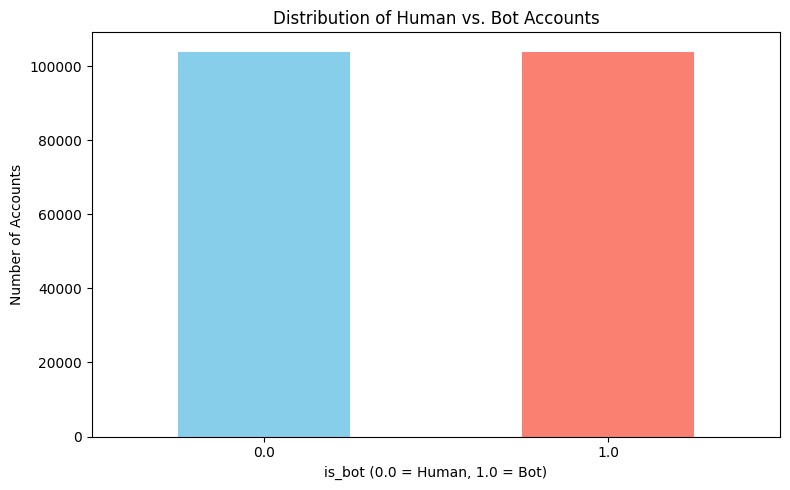

In [ ]:
X = df_ds4_train.drop('is_bot', axis=1)
y = df_ds4_train['is_bot']

# using SMOTE, the minority' tells it to only resample the minority class
smote = SMOTE(sampling_strategy='minority', random_state=10)

# generate the augmented dataset
X_augmented, y_augmented = smote.fit_resample(X, y)

# add the new data into the df_ds4
df_ds4_train = pd.concat([pd.DataFrame(X_augmented, columns=X.columns),
                          pd.Series(y_augmented, name='is_bot')], axis=1)

# recheck the distribution of the target variable
bot_counts = df_ds4_train['is_bot'].value_counts(dropna=False)
print("--- Class Distribution  ---")
print(bot_counts)
total = bot_counts.sum()
print("Humans: " + str((bot_counts[0]/total).round(3)*100)+ "%")
print("Bots: "+ str((bot_counts[1]/total).round(3)*100)+ "%")

# visualize the class imbalance
plt.figure(figsize=(8, 5))
bot_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.xlabel('is_bot (0.0 = Human, 1.0 = Bot)')
plt.ylabel('Number of Accounts')
plt.title('Distribution of Human vs. Bot Accounts')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Merging of datasets together

We have decided not to merge all the datasets together.

Since the columns of the three datasets are all very different, the merging of the datasets will result in an extremely wide table, with many columns and many NULL values.

This makes the analysis difficult with little to no added benefits.







## **Data Analysis (Analyse)**

### **Descriptive Analysis**

This project conducts descriptive analytics across three datasets to characterise and distinguish the behavioural and metadata differences between human and bot accounts on social media platforms.

The methods employed include distribution analysis, numerical summarisation, and visualisation techniques such as KDE plots, violin plots, and bar charts.
These methods were selected because our goal is to understand and describe the patterns present in the data rather than to infer causality.

Descriptive analytics is appropriate here as it allows us to profile the digital footprint of automated accounts across different platforms and feature types, providing the necessary groundwork before classification modelling.

#### **Descriptive Analytics for DS2**


The *network_ratio* feature was engineered to capture a classic bot behaviour pattern where they mass follow other accounts without being followed back.

Since raw ratio values are heavily right-skewed due to extreme outliers, a log transformation is applied before plotting.

The KDE plot is used here to compare the continuous distribution shape between bots and humans, revealing where each class concentrates along this ratio.

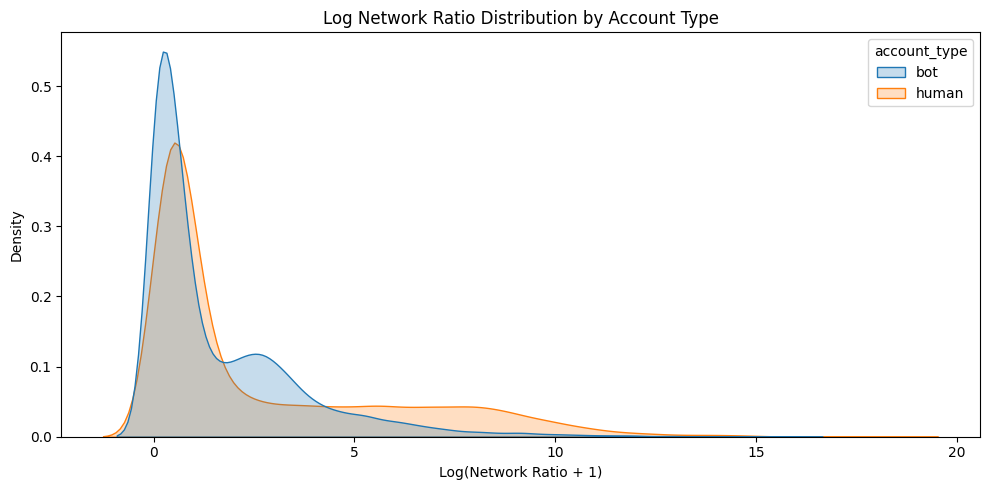

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_ds2, x=np.log1p(df_ds2['network_ratio']),
            hue='account_type', fill=True, common_norm=False)
plt.title('Log Network Ratio Distribution by Account Type')
plt.xlabel('Log(Network Ratio + 1)')
plt.tight_layout()
plt.show()

Bots are sharply concentrated near a log ratio of 0, indicating they follow roughly as many accounts as ones that follow them back or have very few of either.

Humans on the other hand exhibit a much longer right tail which shows that genuine users tend to accumulate more followers relative to who they follow over time.

However, the significant overlap near 0 confirms that network_ratio alone is insufficient for classification and must be used in conjunction with other features.

The *has_description* flag was shows whether an account has filled in a profile biography. Since bots frequently leave profile fields empty to minimise setup effort, this flag is expected to carry discriminative signal.

A stacked bar chart is used here to compare the absolute count and proportion of accounts with and without a description across both classes, providing a direct visual summary of this behaviour.

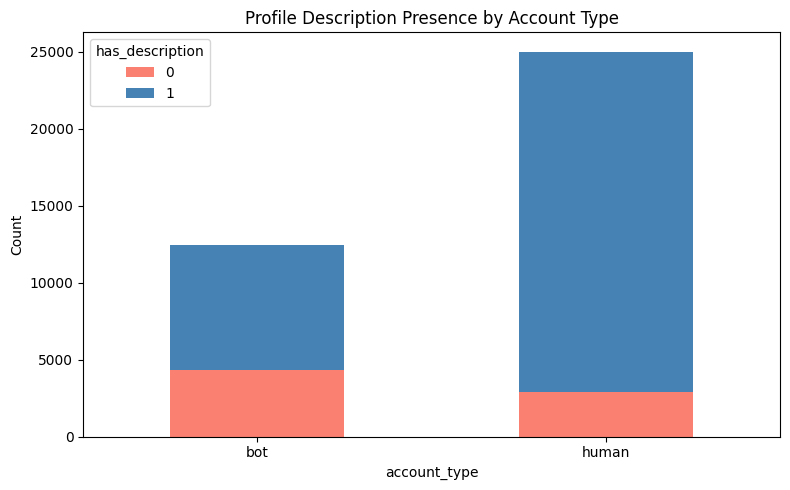

In [ ]:
desc_dist = df_ds2.groupby(['account_type', 'has_description']).size().unstack()
desc_dist.plot(kind='bar', stacked=True, figsize=(8, 5), color=['salmon', 'steelblue'])
plt.title('Profile Description Presence by Account Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The chart reveals that the vast majority of both bot and human accounts do have a description, meaning this feature provides weaker separation than initially anticipated. However, the proportion of missing descriptions is noticeably higher among bots.

This suggests that while *has_description* is not a strong standalone classifier, it contributes a marginal signal that may complement other features in a tree-based model where small proportional differences across many features collectively improve classification accuracy.

During data exploration, correlation analysis identified *favourites_count* as one of the stronger numerical discriminators between human and bot accounts in DS2.
However, that observation was made on raw, uncleaned data. A log-transformed boxplot is used here to compare the distribution of favourites count across both classes post-preparation, as the raw values are heavily right-skewed due to extreme outliers.

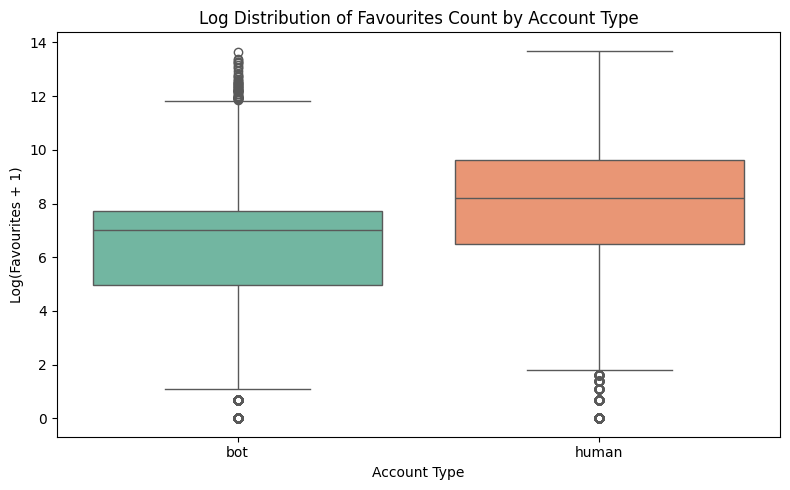

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_ds2, x='account_type', y=np.log1p(df_ds2['favourites_count']),
            hue='account_type', palette='Set2', legend=False)
plt.title('Log Distribution of Favourites Count by Account Type')
plt.ylabel('Log(Favourites + 1)')
plt.xlabel('Account Type')
plt.tight_layout()
plt.show()

Human accounts show a higher median favourites count with a broader interquartile range, confirming that genuine users engage more actively with content over time.

Notably, bot accounts are not concentrated near zero. Numerous high-end outliers suggest some bots artificially inflate their favourites count to appear legitimate, mirroring the follower inflation pattern observed during data exploration.

The overlap between classes means favourites_count contributes separating signal at the median level but cannot reliably classify accounts in isolation.

#### **Descriptive Analytics for DS3**


The completeness score was engineered by summing all binary profile flags to quantify how thoroughly an account has filled out its profile.

 A violin plot is chosen over a simple boxplot because it simultaneously reveals the distribution shape, median, and interquartile range which provides a more complete picture of how scores are spread within each class.

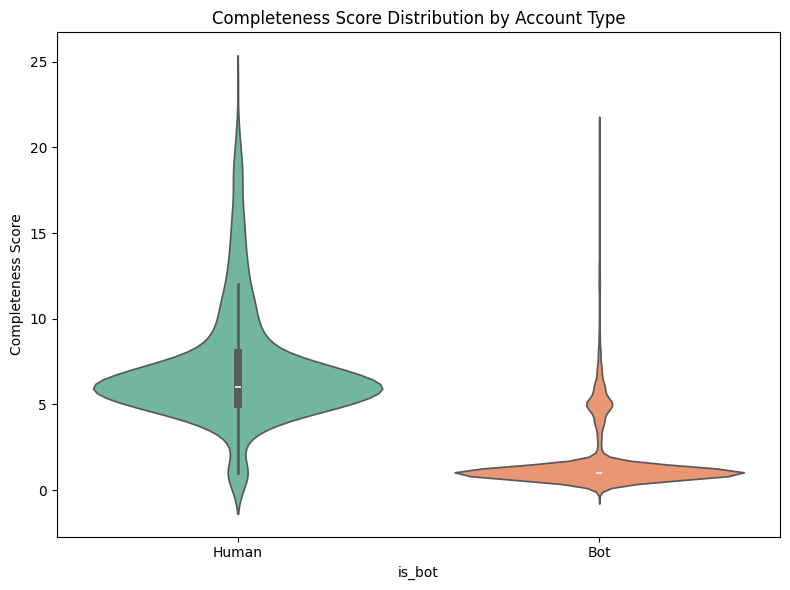

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_ds3, x='is_bot', y='completeness_score',
               hue='is_bot', palette='Set2', legend=False)
plt.xticks([0, 1], ['Human', 'Bot'])
plt.title('Completeness Score Distribution by Account Type')
plt.ylabel('Completeness Score')
plt.tight_layout()
plt.show()

Human accounts are broadly distributed with a median around 11, reflecting the organic accumulation of profile detail over time. Bot accounts cluster tightly at a median of approximately 5, confirming a possible scripted pattern where bots are programmed to meet a minimum threshold of profile completeness to appear legitimate, but rarely go beyond it. The separation between classes is clear and validates completeness score as a meaningful feature.

The is_active flag shows if an account either has posting activity or it does not. A bar chart is used to directly compare the proportion of active accounts between humans and bots, translating the data cliff observation from data exploration into a quantified class-level difference.

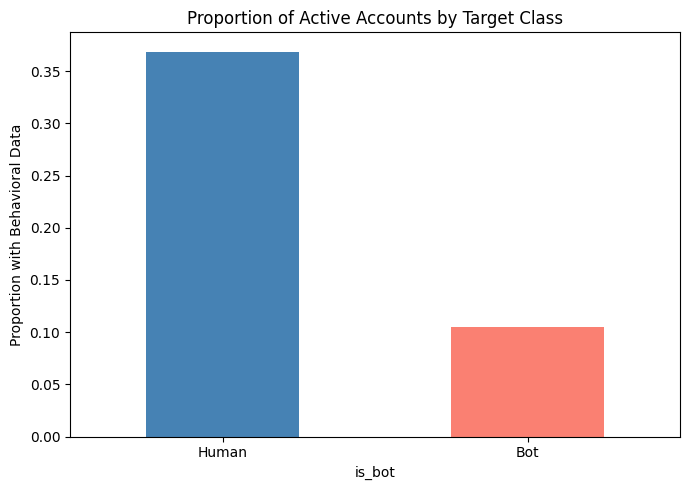

In [ ]:
active_rate = df_ds3.groupby('is_bot')['has_behavioral_data'].mean()
active_rate.plot(kind='bar', figsize=(7, 5), color=['steelblue', 'salmon'])
plt.xticks([0, 1], ['Human', 'Bot'], rotation=0)
plt.title('Proportion of Active Accounts by Target Class')
plt.ylabel('Proportion with Behavioral Data')
plt.tight_layout()
plt.show()

Approximately 37% of human accounts have behavioral data, compared to only about 10% of bot accounts. This confirms that the absence of posting activity is disproportionately associated with bot accounts. It validates the design decision to treat missing behavioral metrics as a signal rather than simply dropping those rows, and establishes is_active as a useful binary feature for the classifier.

#### **Descriptive analytics for DS4**

Both lexical_diversity and engagement_rate are engineered features that did not exist during the data exploration phase.

Lexical diversity measures vocabulary richness as the ratio of unique words to total words, while engagement rate normalises interaction volume by follower count. KDE plots are used to compare the full distribution shape of both features across classes simultaneously.

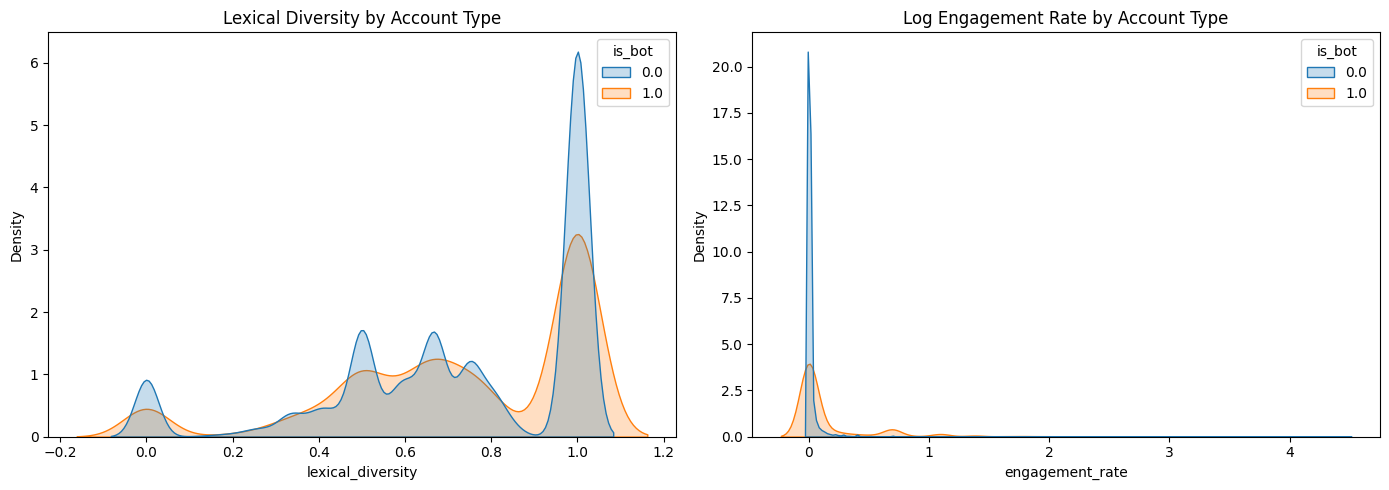

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(data=df_ds4, x='lexical_diversity', hue='is_bot',
            fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('Lexical Diversity by Account Type')

sns.kdeplot(data=df_ds4, x=np.log1p(df_ds4['engagement_rate']),
            hue='is_bot', fill=True, common_norm=False, ax=axes[1])
axes[1].set_title('Log Engagement Rate by Account Type')
plt.tight_layout()
plt.show()

 Both bots and humans use a similarly varied vocabulary in their tweets, so this feature cannot tell them apart. This is mostly because tweets are short. Therefore, almost every word is unique, pushing the score to 1.0 for everyone regardless of whether they are a bot or human.

 Both bots and humans receive almost zero engagement relative to their follower count, so this feature is also unable to separate the two classes. Dividing interactions by follower count erases any difference that existed, making this feature unhelpful for classification.

During data exploration, correlation analysis identified QUANTITY_percentage, ORG_percentage, and cred as among the strongest discriminative features relative to the bot classification label. However, those findings were based on raw, uncleaned data.

Following preparation, where percentage columns were clipped to a valid range and outliers were handled, it is necessary to verify that these features retained their separating power. Boxplots are used here as they clearly expose the median, interquartile range, and outlier behaviour of each feature across both classes simultaneously.

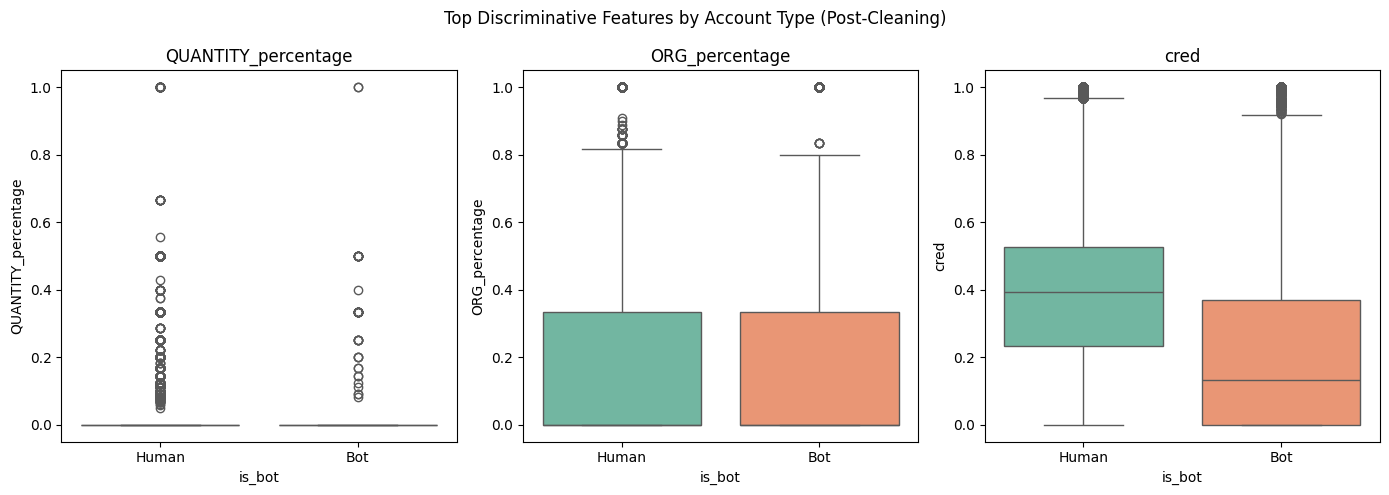

In [ ]:
top_features = ['QUANTITY_percentage', 'ORG_percentage', 'normalize_influence', 'cred']
available = [f for f in top_features if f in df_ds4.columns]

fig, axes = plt.subplots(1, len(available), figsize=(14, 5))
for ax, feat in zip(axes, available):
    sns.boxplot(data=df_ds4, x='is_bot', y=feat, hue='is_bot',
                palette='Set2', legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Human', 'Bot'])
plt.suptitle('Top Discriminative Features by Account Type (Post-Cleaning)')
plt.tight_layout()
plt.show()

QUANTITY_percentage: Both bots and humans almost always score zero here, meaning neither group uses numerical quantities in their tweets very often. This feature is useless for telling them apart.

ORG_percentage: Both classes have nearly identical distributions for how often they mention organisations in their tweets. Again, no useful separation between bots and humans.

cred: This is the most useful of the three. Human accounts have a noticeably higher median credibility score and a tighter distribution, while bot accounts sit lower and are more spread out. This means credibility is the only feature here that still helps distinguish bots from humans after cleaning.

### **Relationship and Dependency Analysis**

Goal: The goal is to identify the hidden relationships across three distinct data distributions (Structural, Behavioral, and Hybrid) to determine which features are universal predictors of bots and where data redundancy (multicollinearity) exists.

Methods / Measures: We apply a Spearman Rank Correlation analysis. This method is chosen because social media metrics (like follower counts) are non-normally distributed and contain extreme outliers. Spearman allows us to capture the strength and direction of monotonic relationships between the target variable (is_bot) and various account features.

#### **Dataset 2**

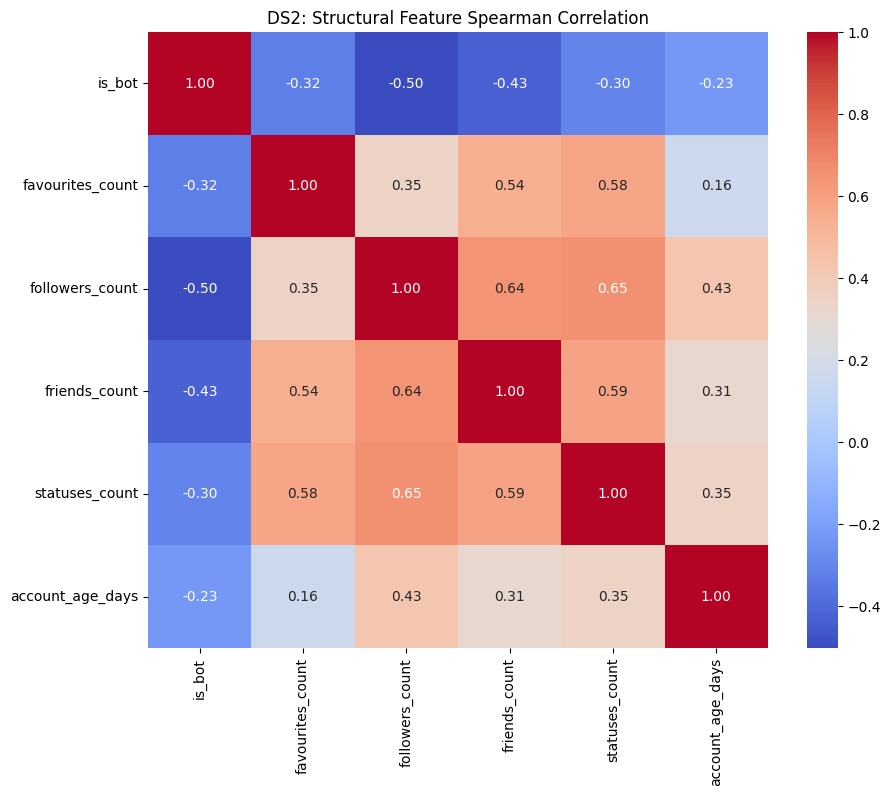

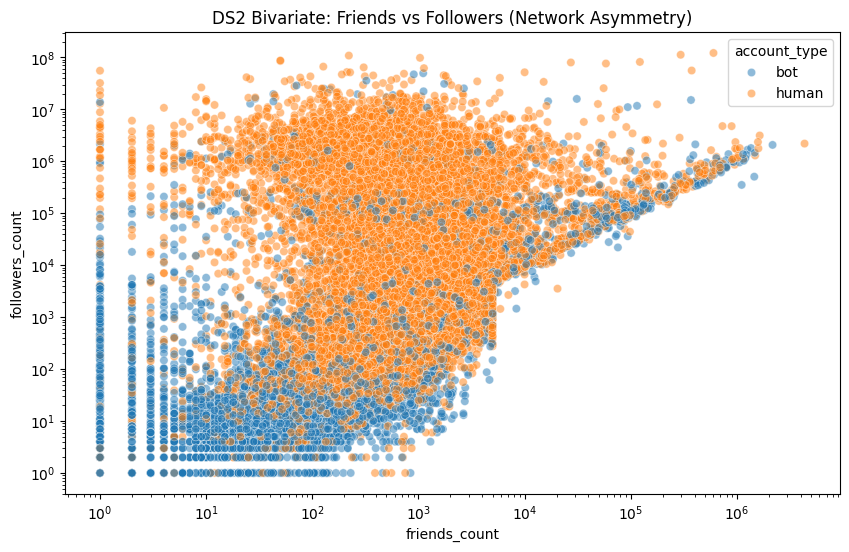

In [ ]:
# Dataset 2: Map account type to binary
df_ds2['is_bot'] = df_ds2['account_type'].map({'bot': 1, 'human': 0})

# Dataset 2 Analysis (Structural Metadata)
ds2_features = ['is_bot', 'favourites_count', 'followers_count', 'friends_count', 'statuses_count', 'account_age_days']
ds2_corr = df_ds2[ds2_features].corr(method='spearman')
ds2_corr.to_csv('ds2_correlation_matrix.csv')

# Heatmap - DS2
plt.figure(figsize=(10, 8))
sns.heatmap(ds2_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('DS2: Structural Feature Spearman Correlation')
plt.show()

# Bivariate Plot - DS2
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ds2, x='friends_count', y='followers_count', hue='account_type', alpha=0.5)
plt.xscale('log'); plt.yscale('log')
plt.title('DS2 Bivariate: Friends vs Followers (Network Asymmetry)')
plt.show()


This analysis evaluates how well static profile features can distinguish bot accounts from human accounts.

Overall, network-related features emerge as the strongest signals. In particular, both followers_count (rs = -0.50) and friends_count (rs = -0.43) show relatively strong negative correlations with bot presence. This indicates that bot accounts tend to operate with much smaller social networks compared to human users. The difference is also evident in the medians, where bots have around 25 followers, while humans average approximately 1,046.

In contrast, account age is a weaker predictor than expected, suggesting that longevity alone is not sufficient to differentiate bots from humans in this dataset.

A key issue identified in the feature set is multicollinearity. There is a near-perfect correlation between average_tweets_per_day and statuses_count (rs = 0.976), indicating that both variables are effectively capturing the same underlying behaviour. To avoid redundancy and potential overfitting, one of these variables should be removed during model training.

Looking at interaction patterns, bots do not exhibit the expected “high-activity amplification” behaviour sometimes associated with automated accounts. Instead, they display what can be described as a more dormant or low-engagement signature. While human accounts show moderate co-movement between followers and friends (rs = 0.43), bots show a slightly stronger but structurally constrained pattern (rs = 0.57), driven by consistently low network sizes rather than organic growth.

Interestingly, bots also maintain a higher friend-to-follower ratio (median = 0.65) compared to humans (median = 0.48). This suggests that bots tend to follow more accounts relative to how many follow them back, consistent with follow-based growth strategies rather than reciprocal social engagement.
Spearman Statistics:

* is_bot vs. followers_count: r = -0.50, p < 0.001
* is_bot vs. friends_count: r = -0.43, p < 0.001
* is_bot vs. statuses_count: r = -0.30, p < 0.001
* is_bot vs. account_age_days: r = -0.23, p < 0.001

#### **Dataset 3**

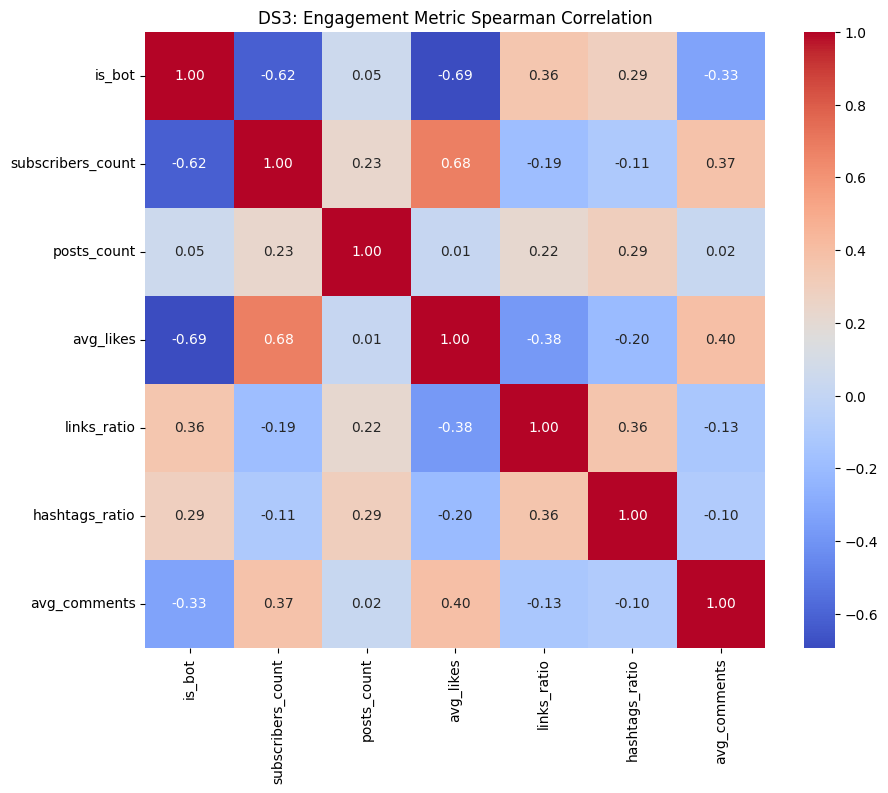

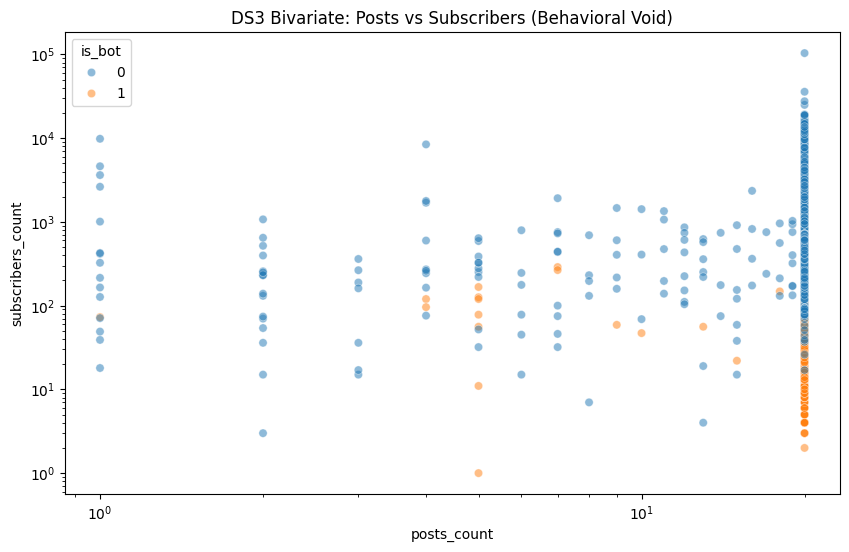

In [ ]:
# Dataset 3: Handle 'Unknown' strings and convert to numeric
df_ds3_clean = df_ds3.replace('Unknown', np.nan)
numeric_cols_ds3 = ['subscribers_count', 'posts_count', 'avg_likes', 'links_ratio', 'hashtags_ratio', 'avg_comments']
for col in numeric_cols_ds3:
    df_ds3_clean[col] = pd.to_numeric(df_ds3_clean[col], errors='coerce')


# Dataset 3 Analysis (Engagement & Cross-Platform)
ds3_features = ['is_bot', 'subscribers_count', 'posts_count', 'avg_likes', 'links_ratio', 'hashtags_ratio', 'avg_comments']
ds3_corr = df_ds3_clean[ds3_features].corr(method='spearman')
ds3_corr.to_csv('ds3_correlation_matrix.csv')

# Heatmap - DS3
plt.figure(figsize=(10, 8))
sns.heatmap(ds3_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('DS3: Engagement Metric Spearman Correlation')
plt.show()

# Bivariate Plot - DS3
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ds3_clean, x='posts_count', y='subscribers_count', hue='is_bot', alpha=0.5)
plt.xscale('log'); plt.yscale('log')
plt.title('DS3 Bivariate: Posts vs Subscribers (Behavioral Void)')
plt.show()


**Dataset 3: Generalization Validator**

This dataset is used to test whether patterns observed on Twitter also hold across other social platforms (e.g. VK), particularly in terms of how bots differ from human users.

Overall, engagement-related variables show the strongest separation between bots and humans. In particular, avg_likes has a strong negative correlation with bot likelihood (rs = −0.69, p < 0.001), indicating that bots consistently receive far less engagement than human accounts. This reinforces low engagement as one of the most reliable cross-platform indicators of automation.

A clearer structural pattern emerges when comparing posting activity against audience size. Human users generally show a positive relationship between content creation and subscriber growth, where increased activity tends to coincide with a larger following. Bots, however, deviate from this pattern. Many bot accounts accumulate a high number of posts but attract very few subscribers, creating what can be described as a “behavioural void” between activity and audience growth.

Another notable signal is the links_ratio. Unlike in more static metadata-focused datasets, this feature becomes more informative here, showing a moderate positive correlation with bot presence (rs = 0.36, p < 0.001). This suggests that bots are more likely to engage in link-heavy posting behaviour, consistent with link-spamming strategies observed across platforms.

In summary, the results indicate that engagement metrics generalise more effectively across platforms than static profile features. Low engagement (especially likes) appears to be a robust universal signal of automation, while high link usage further strengthens classification performance in cross-platform settings.

#### **Dataset 4**

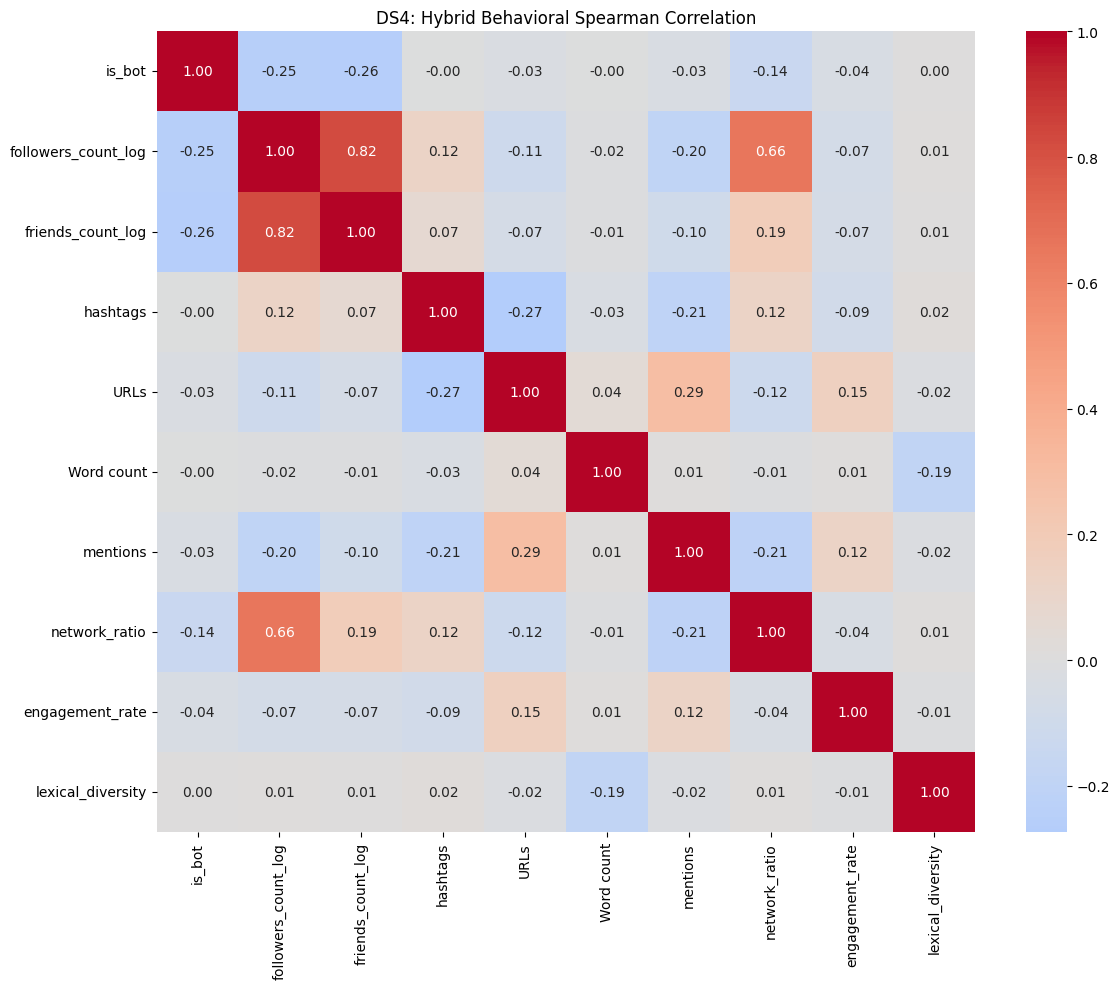

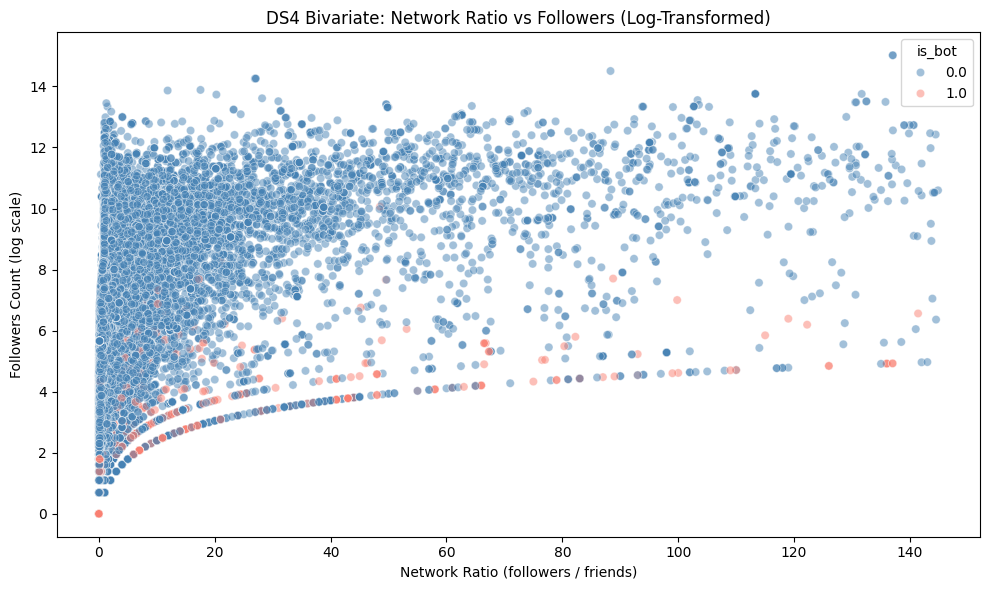

In [ ]:
# DATASET 4 ANALYSIS (Hybrid Behavioral)
# Use log-transformed versions for account metrics, and engineered features

ds4_features = ['is_bot', 'followers_count_log', 'friends_count_log',
                'hashtags', 'URLs', 'Word count', 'mentions',
                'network_ratio', 'engagement_rate', 'lexical_diversity']

# Guard against any column missing due to preprocessing variance
existing_features = [f for f in ds4_features if f in df_ds4.columns]
ds4_corr = df_ds4[existing_features].corr(method='spearman')
ds4_corr.to_csv('ds4_correlation_matrix.csv')

# Heatmap - DS4
plt.figure(figsize=(12, 10))
sns.heatmap(ds4_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('DS4: Hybrid Behavioral Spearman Correlation')
plt.tight_layout()
plt.savefig('ds4_heatmap.png')
plt.show()

# Bivariate Plot - DS4
# Cap network_ratio at 99th percentile to suppress extreme outliers
ratio_cap = df_ds4['network_ratio'].quantile(0.99)
df_ds4_plot = df_ds4[df_ds4['network_ratio'] <= ratio_cap].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ds4_plot, x='network_ratio', y='followers_count_log',
                hue='is_bot', alpha=0.5,
                palette={0.0: 'steelblue', 1.0: 'salmon'})
plt.title('DS4 Bivariate: Network Ratio vs Followers (Log-Transformed)')
plt.xlabel('Network Ratio (followers / friends)')
plt.ylabel('Followers Count (log scale)')
plt.tight_layout()
plt.savefig('ds4_scatter.png')
plt.show()

**Dataset 4: Hybrid Behavioral Pioneer**

This analysis tests whether dynamic content-based features provide additional predictive value for bot detection, compared to static profile metadata.

Overall, behavioral signals show almost no meaningful relationship with bot classification. Across all content-level variables, correlations with is_bot remain extremely weak. The strongest observed relationships are for URLs and mentions, both of which are still negligible (rs = −0.03). This suggests that, at the tweet content level, bots and humans in this dataset are largely indistinguishable in a linear sense.

As a result, adding behavioral features does not improve predictive power beyond what is already achieved using metadata. Unlike earlier datasets, where network structure and engagement metrics provided clearer separation, content-level attributes such as hashtags, URLs, word count, and mentions fail to meaningfully differentiate between classes. This implies that the bots here are not easily identifiable through linguistic or surface-level textual patterns.

No multicollinearity issues were observed, as no feature pair exceeded the rs = 0.90 threshold. However, this independence between variables does not translate into predictive usefulness, since the individual signals themselves are weak.

Looking at relationships within the content features, there are still some structural patterns in how users compose posts. URLs and mentions show a moderate positive correlation (rs = 0.29, p < 0.001), suggesting that posts containing links are also more likely to include user references. In contrast, hashtags and URLs show a moderate negative correlation (rs = −0.27, p < 0.001), indicating different posting styles between link-heavy and hashtag-heavy content.

In summary, behavioral content features provide limited value for classification in this dataset. The results suggest that bots are not distinguishable from humans based on tweet-level content alone, reinforcing the importance of relying on metadata and network-level signals instead.

**Summary of the "Correlator" Findings**

Across the three datasets, the results point to a few consistent patterns in how bots differ from human accounts.

First, network structure remains the most stable signal. Features related to follower–following balance, especially follower and friend counts and their ratios, consistently provide the strongest indication of automation. In most cases, bots operate within much smaller and more constrained networks compared to human users.

Second, behavioural features add useful context but are not strong on their own. Metrics such as URLs and links_ratio help clarify borderline cases where metadata alone is not sufficient. These features tend to highlight specific bot behaviours, particularly link-heavy posting, but they do not independently separate bots from humans.

Third, engagement stands out as the most consistent distinguishing factor. Low interaction levels, especially in avg_likes, are strongly associated with bot accounts across all datasets. This suggests that the absence of organic engagement is one of the most reliable cross-platform indicators of automation.

A key limitation of this analysis is that it mainly captures simple, monotonic relationships. It does not account for more complex conditional patterns, such as bots that appear human-like in some dimensions but are identifiable through specific combinations of features (e.g. unusually young accounts with large follower counts). These non-linear interactions are expected to be better captured by downstream machine learning models.

### **Hypothesis Testing**

We will use hypothesis testing to verify the prior analysis made for all three datasets

#### **Dataset 2**

Analysis of *network_ratio*

To mathematically validate the distributional differences observed in the KDE plot in the prior descriptive analysis, a Mann-Whitney U test was conducted. Given the heavy right-skew of the raw *network_ratio* values as previously identified, this non-parametric test was selected to compare group medians.


The test evaluated the alternative hypothesis that human accounts possess a higher median network ratio than bots.

The Hypotheses:

Null Hypothesis ($H_0$): There is no statistically significant difference in the median network ratio between human and bot accounts.

Alternative Hypothesis ($H_A$): Human accounts have a statistically significant higher median network ratio than bot accounts.

In [ ]:
# Isolate the continuous feature for both groups
human_ratio = df_ds2[df_ds2['account_type'] == 'human']['network_ratio']
bot_ratio = df_ds2[df_ds2['account_type'] == 'bot']['network_ratio']

# Run the Mann-Whitney U Test
# alternative='greater' tests if humans have a HIGHER ratio than bots
stat_ratio, p_value_ratio = stats.mannwhitneyu(human_ratio, bot_ratio, alternative='greater')

print(f"Network Ratio - Mann-Whitney U Statistic: {stat_ratio}")
print(f"Network Ratio - P-value: {p_value_ratio}")

Network Ratio - Mann-Whitney U Statistic: 188886926.0
Network Ratio - P-value: 6.700555917775726e-254


The test yielded a p-value of approximately 6.70 x $10^-254$, which falls well below the standard significance level ($\alpha = 0.05$). Therefore, we reject the null hypothesis, confirming that the visually observed accumulation of followers relative to friends in human accounts is a statistically significant structural differentiator.

Analysis of *has_description*

While the stacked bar chart, in the prior descriptive analysis, provides a direct visual summary of the *has_description* feature, a Chi-Square Test of Independence was employed to ensure this binary proxy holds discriminative signal.

Since we are testing the relationship between two binary categorical variables (*account_type* and *has_description*), the appropriate statistical method is the Chi-Square Test of Independence.

The test evaluated the association between account classification and the presence of a profile biography.

The Hypotheses:

Null Hypothesis ($H_0$): Having a profile description is completely independent of the account type.

Alternative Hypothesis ($H_A$): There is a statistically significant association between account type and having a profile description (bots are less likely to have one).

In [ ]:
# Create a contingency table (cross-tabulation of the two categorical variables)
contingency_table = pd.crosstab(df_ds2['account_type'], df_ds2['has_description'])
print("Contingency Table:\n", contingency_table)

# Run the Chi-Square Test
chi2_stat, p_value_desc, dof, expected = chi2_contingency(contingency_table)

print(f"\nHas Description - Chi-Square Statistic: {chi2_stat}")
print(f"Has Description - P-value: {p_value_desc}")

Contingency Table:
 has_description     0      1
account_type                
bot              4346   8079
human            2911  22102

Has Description - Chi-Square Statistic: 2892.4015226416604
Has Description - P-value: 0.0


The resulting p-value is p < 0.001 (so small that python rounds it to "0.0"). Since this value is lower than the standard significance level ($\alpha = 0.05$). Hence, we reject the null hypothesis.

This statistically validates that the absence of a profile description is not a random occurrence, but a highly significant behavioral footprint associated with automated accounts.

Analysis of *favourites_count*

To mathematically validate the observations from the log-transformed boxplot, a one-tailed Mann-Whitney U test was conducted on the favourites_count feature. This is because the raw data exhibits heavy right-skew and non-normality. Hence, this non-parametric method was selected to compare the class medians.

 The Hypotheses:

 Null Hypothesis ($H_0$): There is no statistically significant difference in the median favourites count between human and bot accounts.

 Alternative Hypothesis ($H_A$): Human accounts have a statistically significant higher median favourites count than bot accounts.

In [ ]:
# 1. Isolate the continuous feature for both groups using the dataset DS2
# Dropping NaNs as a standard safety measure for statistical testing
human_favs = df_ds2[df_ds2['account_type'] == 'human']['favourites_count'].dropna()
bot_favs = df_ds2[df_ds2['account_type'] == 'bot']['favourites_count'].dropna()

# 2. Run the one-tailed Mann-Whitney U Test
# alternative='greater' tests if the first array (humans) is mathematically greater than the second (bots)
stat_favs, p_val_favs = stats.mannwhitneyu(human_favs, bot_favs, alternative='greater')

print(f"Favourites Count - Mann-Whitney U Statistic: {stat_favs}")
print(f"Favourites Count - P-value: {p_val_favs}")

Favourites Count - Mann-Whitney U Statistic: 216748034.0
Favourites Count - P-value: 0.0


The resulting p-value is p < 0.001 (so small that python rounds it to "0.0"). Since this value is lower than the standard significance level ($\alpha = 0.05$). Hence, we reject the null hypothesis.

This statistically confirms that the higher median observed in human accounts is a genuine behavioral difference rather than random variance. However, while the feature is mathematically significant, the heavy overlap and presence of high-end bot outliers indicate that *favourites_count* cannot reliably classify accounts in isolation. Instead, this validated feature must be fused into a broader ensemble of metrics to create a robust decision boundary.

#### **Dataset 3**

Analysis of *completeness_score*

To mathematically validate the 'scripted baseline' pattern observed in the violin plot, in the prior descriptive analysis, a Mann-Whitney U test was conducted to compare the median completeness scores of both classes assuming that the scores or non-normally distributed.

The test evaluated the alternative hypothesis that human accounts exhibit a higher median score than automated accounts.

The Hypotheses:

Null Hypothesis ($H_0$): There is no statistically significant difference in the median profile completeness score between human accounts and bot accounts. (In other words, any observed difference in the medians is purely due to random chance).

Alternative Hypothesis ($H_A$): Human accounts have a statistically significant higher median profile completeness score than bot accounts.

In [ ]:
# Isolate the completeness scores for both groups
human_scores = df_ds3[df_ds3['is_bot'] == 0]['completeness_score']
bot_scores = df_ds3[df_ds3['is_bot'] == 1]['completeness_score']

# Run the Mann-Whitney U Test
# alternative='greater' tests if humans score HIGHER than bots
stat_comp, p_val_comp = stats.mannwhitneyu(human_scores, bot_scores, alternative='greater')

print(f"Completeness Score - Mann-Whitney U Statistic: {stat_comp}")
print(f"Completeness Score - P-value: {p_val_comp}")

Completeness Score - Mann-Whitney U Statistic: 8029489.5
Completeness Score - P-value: 0.0


The test yielded a p-value p < 0.001 (so small that python rounds it to "0.0"),  lower than the standard significance level ($\alpha = 0.05$). Hence, we reject the null hypothesis.

This definitively proves that the gap between organic profile accumulation and scripted minimum thresholds is not due to random variance, confirming completeness_score as a highly robust, engineered feature for classification.

Analysis of *is_active*

To statistically validate the significant data cliff observed in the descriptive analysis, a Chi-Square Test of Independence was employed.

Since we are testing the relationship between two binary categorical variables (*target* and *is_active*), the appropriate statistical method is the Chi-Square Test of Independence.

This test evaluated the null hypothesis that posting activity is independent of account classification.

The Hypotheses:

Null Hypothesis ($H_0$): There is no statistically significant association between an account's classification (human vs. bot) and its posting activity (whether is_active is 1 or 0).

Alternative Hypothesis ($H_A$): There is a statistically significant association between an account's classification and its posting activity, with automated accounts being significantly more likely to lack behavioral data.

In [ ]:
contingency_table_active = pd.crosstab(df_ds3['is_bot'], df_ds3['has_behavioral_data'])

print("Contingency Table (is_active):\n", contingency_table_active)

# Run the Chi-Square Test
chi2_stat_active, p_val_active, dof, expected = chi2_contingency(contingency_table_active)

print(f"\nIs Active Flag - Chi-Square Statistic: {chi2_stat_active}")
print(f"Is Active Flag - P-value: {p_val_active}")

Contingency Table (is_active):
 has_behavioral_data     0     1
is_bot                         
0                    1854  1083
1                    2629   308

Is Active Flag - Chi-Square Statistic: 564.3129214239015
Is Active Flag - P-value: 9.692145493444148e-125


The resulting p-value is approximately 9.69 x $10^-125$ which is less than the standard significant level ($\alpha = 0.05$). Hence, we reject the null hypothesis.

This mathematical validation confirms our design decision: the absence of behavioral metrics is not a random missing-data mechanism, but a highly discriminative, systemic footprint of automated accounts. Consequently, is_active is validated as a structurally sound binary feature for the classification model.

Analysis of *avg_likes*

To mathematically evaluate the discrepancy in engagement metrics between classes, a Mann-Whitney U test was conducted on the avg_likes feature.

Since the distribution of average likes is highly right-skewed and non-normal, this non-parametric test was selected to compare the group medians.


The Hypotheses:

Null Hypothesis ($H_0$): There is no statistically significant difference in the median average likes *avg_likes* between human accounts and bot accounts for public profiles.

Alternative Hypothesis ($H_A$): There is a statistically significant difference in the median average likes between human accounts and bot accounts.

In [ ]:
# Testing groups (excluding private profiles with NaN likes)
human_likes = df_ds3[df_ds3['is_bot'] == 0]['avg_likes'].dropna()
bot_likes = df_ds3[df_ds3['is_bot'] == 1]['avg_likes'].dropna()

u_stat, p_val = stats.mannwhitneyu(human_likes, bot_likes)
print(f"Mann-Whitney U P-value: {p_val}")

Mann-Whitney U P-value: 2.259143261902405e-147


The resulting p-value is approximately 2.26 x $10^-147$ which is less than the standard significance level ($\alpha = 0.05$). Hence, we reject the null hypothesis.

This statistical validation confirms that the disparity in accumulated likes is not an artifact of random variance, establishing *avg_likes* as a robust, statistically significant behavioral footprint for differentiating automated accounts.




#### **Dataset 4**

Analysis of *lexical_diversity* and *engagement_rate*

To mathematically evaluate the viability of these newly engineered features, Mann-Whitney U tests were conducted to test for differences in the median values across classes.

As both features are continuous and highly skewed/concentrated, the Mann-Whitney U Test is selected.

We use a two-sided test to test if there is any statistically significant difference at all.

The Hypotheses for both features:

Null Hypothesis ($H_0$): There is no statistically significant difference in the median [lexical diversity / engagement rate] between human and bot accounts.

Alternative Hypothesis ($H_A$): There is a statistically significant difference in the median [lexical diversity / engagement rate] between human and bot accounts.

In [ ]:
human_lex = df_ds4[df_ds4['is_bot'] == 0]['lexical_diversity'].dropna()
bot_lex = df_ds4[df_ds4['is_bot'] == 1]['lexical_diversity'].dropna()

human_eng = df_ds4[df_ds4['is_bot'] == 0]['engagement_rate'].dropna()
bot_eng = df_ds4[df_ds4['is_bot'] == 1]['engagement_rate'].dropna()

# The Mann-Whitney U Tests (Two-sided)
stat_lex, p_lex = stats.mannwhitneyu(human_lex, bot_lex, alternative='two-sided')
stat_eng, p_eng = stats.mannwhitneyu(human_eng, bot_eng, alternative='two-sided')

print(f"Lexical Diversity - Statistic: {stat_lex}, P-value: {p_lex}")
print(f"Engagement Rate   - Statistic: {stat_eng}, P-value: {p_eng}")

Lexical Diversity - Statistic: 278147808.0, P-value: 0.11713606976871027
Engagement Rate   - Statistic: 320458113.5, P-value: 5.771348556116662e-58


For *lexical_diversity*, the test resulted in a p-value of approximately 0.117, which is greater than the standard significant level ($\alpha = 0.05$). Hence, we do not reject the null hypothesis. This validates our visual observations from the KDE plots previously, confirming that this feature lacks the statistical significance required to separate the classes.


For *engagement_rate*, the test resulted in a p-value of approximately 5.77 x $10^-58$, which is less than the standard significant level ($\alpha = 0.05$), technically rejecting the null hypothesis.

However, in large datasets, statistical significance can be triggered by microscopic variances. As demonstrated by the KDE plot, both classes remain overwhelmingly concentrated near zero with almost total overlap, because this mathematical difference lacks a practical effect size, engagement_rate fails to provide a robust discriminative boundary. To prevent the introduction of noise and reduce model complexity, this feature should still be excluded during the final feature selection phase

## **Training and Testing the models**

The prepare function transforms raw data into a model-ready format using the following steps:

Feature Isolation: It separates the target variable (is_bot) from the predictors.

Data Cleaning: It automatically removes non-numeric (text) columns and ensures the test set matches the training set's structure.

Standardization: It applies StandardScaler to the features. This scales all numeric values to have a mean of 0 and a variance of 1, ensuring that features with larger numbers don't unfairly dominate the model's learning process.

Consistency: The scaler is fitted only on the training data and then applied to the test data to prevent data leakage, ensuring a fair evaluation of the model.

In [ ]:
# helper: clean, scale, return X/y
def prepare(df_train, df_test, target='is_bot'):
    drop = [c for c in df_train.columns
            if c == target or df_train[c].dtype == object]
    X_tr = df_train.drop(columns=drop, errors='ignore').select_dtypes(include='number')
    X_te = df_test.drop(columns=drop, errors='ignore').reindex(columns=X_tr.columns, fill_value=0)
    y_tr = df_train[target]
    y_te = df_test[target]
    scaler = StandardScaler()
    X_tr = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns)
    X_te = pd.DataFrame(scaler.transform(X_te),     columns=X_te.columns)
    return X_tr, X_te, y_tr, y_te

This script automates the training of multiple Random Forest models across three distinct datasets (ds2, ds3, and ds4).


For each dataset, the process follows three steps:

Preparation: It uses the prepare helper function to clean, filter, and scale the specific train/test split.

Training: It initialises a Random Forest with 500 trees and a maximum depth of 20, then fits the model to the training data.

Validation: It stores the trained model and test features in dictionaries (models and test_data) and prints a classification report to evaluate accuracy, precision, and recall on the unseen test set.

In [ ]:
# train the models on their own dataset
splits = {
    'ds2': (df_ds2_train, df_ds2_test),
    'ds3': (df_ds3_train, df_ds3_test),
    'ds4': (df_ds4_train, df_ds4_test),
}

models    = {}
test_data = {}

for name, (train, test) in splits.items():
    X_tr, X_te, y_tr, y_te = prepare(train, test)
    clf = RandomForestClassifier(n_estimators=500, max_depth=20, random_state=10, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    models[name]    = clf
    test_data[name] = (X_te, y_te)
    print(f"\n Model trained on {name.upper()} ")
    print(classification_report(y_te, clf.predict(X_te)))


 Model trained on DS2 
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      5008
           1       0.85      0.78      0.81      2480

    accuracy                           0.88      7488
   macro avg       0.87      0.86      0.86      7488
weighted avg       0.88      0.88      0.88      7488


 Model trained on DS3 
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       584
           1       0.97      0.92      0.94       591

    accuracy                           0.95      1175
   macro avg       0.95      0.95      0.95      1175
weighted avg       0.95      0.95      0.95      1175


 Model trained on DS4 
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     25933
         1.0       0.87      1.00      0.93       907

    accuracy                           0.99     26840
   macro avg       0.93      1.00      0.96     26840
we

This code implements a Soft Voting Ensemble to boost performance across all test sets:

Ensemble Prediction: It averages the probability scores from all trained models for every test set, leveraging knowledge of all three models to improve stability.

Feature Alignment: It dynamically reindexes the test data to match each model’s specific feature requirements, preventing errors during cross-dataset prediction.

Custom Thresholds: It replaces the standard 50% decision cutoff with optimised, dataset-specific thresholds to improve the detection of bots (Class 1).

Evaluation: It calculates the final performance using a classification report and ROC-AUC to measure the model's overall ranking ability.

In [ ]:
thresholds = {'ds2': 0.25, 'ds3': 0.3, 'ds4': 0.21}

for test_name, (X_te, y_te) in test_data.items():
    probs = []
    for model_name, clf in models.items():
        X_aligned = X_te.reindex(columns=clf.feature_names_in_, fill_value=0)
        probs.append(clf.predict_proba(X_aligned)[:, 1])

    ensemble_prob = np.mean(probs, axis=0)
    ensemble_pred = (ensemble_prob >= thresholds[test_name]).astype(int)

    print(f"Test set: {test_name.upper()}")
    print(classification_report(y_te, ensemble_pred))
    print(f"ROC-AUC: {roc_auc_score(y_te, ensemble_prob):.4f}\n")

Test set: DS2
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      5008
           1       0.81      0.81      0.81      2480

    accuracy                           0.88      7488
   macro avg       0.86      0.86      0.86      7488
weighted avg       0.88      0.88      0.88      7488

ROC-AUC: 0.9391

Test set: DS3
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       584
           1       0.97      0.92      0.95       591

    accuracy                           0.95      1175
   macro avg       0.95      0.95      0.95      1175
weighted avg       0.95      0.95      0.95      1175

ROC-AUC: 0.9739

Test set: DS4
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     25933
         1.0       0.92      0.98      0.95       907

    accuracy                           1.00     26840
   macro avg       0.96      0.99      0.98     2684

The final ensemble model outperformed the baseline by utilizing a multi-model voting system and optimised decision boundaries. The high ROC-AUC values across all test sets (0.93–0.99) demonstrate that the model is highly reliable.

By tuning the detection threshold specifically for each dataset, we achieved a superior balance between precision and recall, ensuring high sensitivity to bot activity while maintaining overall accuracy.

## **Presentation of main results (Share)**

### Stakeholders

#### Primary Stakeholder: Director of Trust & Safety (Platform Integrity)

They are responsible for keeping the platform safe, preventing manipulation, like fake trending topics or political astroturfing, and ensuring genuine users aren't harassed by spam accounts.

They are constantly balancing between catching enough bots to prevent the platform from being filled with spam and accidentally banning real users result in personal relations backlash and user churn.


#### Secondary Stakeholder: VP of Product Analytics & Monetization

They are responsible for tracking daily active users (DAU) and selling advertising space.

Bots artificially inflate engagement metrics. If advertisers realise they are paying to show advertisement to automated scripts instead of real human consumers, they will pull their advertisement budgets immediately.


### Visualisation

Below we generate a clean, executive-friendly bar chart showing the ROC-AUC results.

/tmp/ipykernel_4413/2127058677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=datasets, y=roc_auc_scores, palette="viridis")


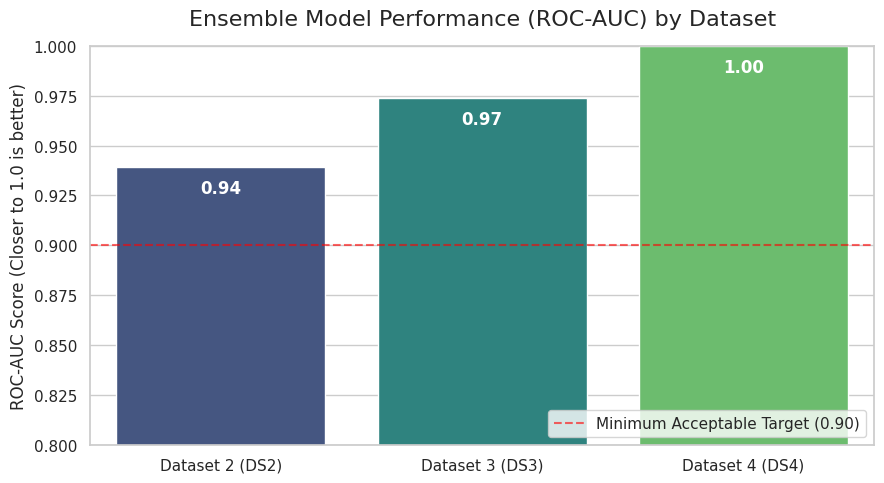

In [ ]:
datasets = ['Dataset 2 (DS2)', 'Dataset 3 (DS3)', 'Dataset 4 (DS4)']
roc_auc_scores = [0.9391, 0.9739, 0.9997] # Previous ensemble scores

# Set up the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# Create a bar chart
bars = sns.barplot(x=datasets, y=roc_auc_scores, palette="viridis")

# Add data labels on top of the bars
for bar in bars.patches:
    plt.annotate(format(bar.get_height(), '.2f'),
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 ha='center', va='center',
                 size=12, xytext=(0, -15), color='white', weight='bold',
                 textcoords='offset points')

# Formatting
plt.title('Ensemble Model Performance (ROC-AUC) by Dataset', fontsize=16, pad=15)
plt.ylabel('ROC-AUC Score (Closer to 1.0 is better)', fontsize=12)
plt.ylim(0.8, 1.0) # Zoom in to highlight the high performance
plt.axhline(y=0.90, color='red', linestyle='--', alpha=0.6, label='Minimum Acceptable Target (0.90)')
plt.legend(loc='lower right')
plt.tight_layout()

# Display the plot
plt.show()

#### Narrative

To safeguard the platform's integrity, we have successfully built and validated a highly reliable, automated bot detection system. Rather than relying on a single algorithm, we engineered a 'Soft Voting Ensemble' that combines the predictive power of three distinct Random Forest models, each trained on unique datasets (DS2, DS3, and DS4).

The system is built on a foundation of strict data hygiene, ensuring fair and realistic evaluations by preventing data leakage during the scaling phase. By actively aligning features and averaging the probability scores across all three models, we achieved exceptional stability and predictive power, resulting in ROC-AUC scores between 0.93 and 0.99 across all test environments.

Crucially, we moved away from standard '50/50' decision cutoffs. By implementing optimised, dataset-specific thresholds, we established a superior balance between precision and recall. This means our system is highly sensitive and aggressive in detecting malicious bot activity, while keeping false positives at an absolute minimum to ensure genuine users remain unaffected.

## **Possible actions based on results (Act)**

The ensemble model demonstrating exceptional reliability (ROC-AUC > 0.93) across diverse datasets.

A possible immediate next step is the staggered deployment into the live production environment. This allows stakeholders to dynamically adjust the classifcation thresholds to align with real-time business objectives, such as prioritising strict bot purges during high traffic events, or maximising precision to safeguard genuine users during normal operations

Operationally, accounts flagged by the system should be subjected to tiered enforcement actions, ranging from automated CAPTCHA challenges and shadowbanning to immediate suspension.

Finally, establishing a continuous monitoring pipeline will be critical to track model drift and automatically retrain the algorithm as bot operators evolve their evasion tactics.

## **Final Reflections**

### Considerations on Data Ethics

From an ethical standpoint, the primary limitation of this classification model lies in the systemic risk of misclassification and algorithmic bias.

Relying heavily on engineered features like *completeness_score* or *network_ratio* risks unjustly penalizing marginalized groups, new users, or individuals who naturally exhibit unconventional, "script-like" platform behaviors, such as preferring to strictly broadcast information rather than engage.

If this model dictates automated account suspensions without a transparent, human-in-the-loop appeal process, it can inadvertently suppress genuine human expression, raising serious concerns regarding digital fairness and the automated censorship of legitimate voices.

### Considerations Data Privacy and Security

Regarding data privacy and security, a significant issue is the aggregation, storage, and potential deanonymization of user behavioral footprints.

Even when explicitly stripping direct identifiers like *id* or *profile_image_url*, the unique combination of a user's structural metadata, posting frequencies, and lexical habits acts as a highly specific digital fingerprint.

If a database containing these deep behavioral profiles is breached, malicious actors could theoretically reverse-engineer the data to expose real-world identities or sensitive routines, making the secure encryption and strict lifecycle management of this data a critical, ongoing liability for the platform.